---
>「見えるぞ！私にも敵が見える！」\
>シャア・アズナブル
---

# 物体検出


## 物体検出手法

画像の中の複数の物体を認識し、その場所をBounding Boxと呼ばれる四角で示す
- さらにセグメンテーションという手法もあり、こちらは塗り分ける

物体検出手法には著名な手法が多く、シンプルにまとめると次のようになる

- Yolo
  - 一連の物体検出手法YOLO（You Only Look Once）の1つで、v2と比較して特に小さいものの検出精度が改善された
  - Yolo V1からYolo V3まで同一作者により設計され、その後は異なる作者によりYolo V4およびYolo V5が提案されている
    - 従って、Yolo V3までがYoloという研究者もいる
  - 傾向として、FPS(認識フレームレート)が速く、その割に精度が高いことを特徴としている
  - 小さい解像度から大きい解像度に情報を伝搬して物体を検出する構造を有する

- SSD
  - YOLOと並び称されることが多いが、SSDではそれぞれの解像度から直接物体を検出する構造を有する
  - 構造的にはSSDもYOLO V3も大きな違いはなく、SSDは情報を一方向のみにしか伝えていないが、YoloV3はGlobal情報とLocal情報の組み合わせを実現している

論文記載のそれぞれのネットワーク構造は次のとおりである

<img src="http://class.west.sd.keio.ac.jp/dataai/text/ssd-yolo.png" width=500>

ここでは、YoloV3を扱い、実際に実装する


# YoLoの設計

## YoLoの原理

画像ごと異なる対象物体の大きさの違いに対応するため、小スケール(Scale1)$13 \times 13$、中スケール$26 \times 26$、大スケール$52 \times 52$の3つの対象の異なる3次元テンソルを得るように学習する
- 例えば、図のScale 1に相当する$13 \times 13$のスケールでは、$13 \times 13$であることから入力画像を$13\times 13$のグリッドで分割する
- さらに各グリッドで3つのBoxを予測するため、これをBox1, Box2, Box3とする
- 各Boxで得られる(得るべき)情報は、Bounding Boxやラベルなどの情報である
  - Bounding boxは、$(tx, ty, tw, th)$で要素数4
  - 検出のObjectness Score(検出対象であるかどうかを表すフラグ)で要素数1
  - 80クラス分類でワンホットのため要素数80
- グリッドセルあたり3つのBoxで$3\times(4+1+80)$つまり255次元の情報が獲得され、これが$13 \times 13$個存在するため、結果的に$13 \times 13 \times 255$となる
- 他も同様である

<img src="http://class.west.sd.keio.ac.jp/dataai/text/yololearn.png" width=800>

上図において、仮にGround TruthのBounding Boxの中心があるグリッドセルの中、例えば、鳥の画像の赤いBoxにあった場合、該当する物体のBoxの予測はこの赤いグリッドセルが担当する
- つまり、同じグリッドセルは3つの物体以上を担当できないという制限がある
- Ground Truth とは学習やテストに使用する実データのこと

赤いセルは鳥のBoxを予測することになり、Objectness Scoreが1に、ほかのセルは0になる
- 各セルは予めサイズの異なる3つのPrior Box(S, M, L)が割り当てられており、Ground Truthと一番大きさの近いPrior Boxを選択する
  - 実際は、Ground truthであるBounding Boxと重なった面積が一番大きいPrior Boxを選択する
- 更に座標オフセットの調整も行う

## Yoloのモデル

### 全体の構造
まず、YoLoV3のモデル構造を示す

<img src="http://class.west.sd.keio.ac.jp/dataai/text/yolov3.png" width=600>

このように、主に75層の畳み込み層から構成されており、先に述べた物体の特徴量を抽出する
- Fully connected層を利用していないため、入力画像のサイズを任意に設定できる
- Pooling Layerを用いず、Strideが2の畳み込み層を用いることでダウンサンプリングを行う
  - スケール不変な特徴量を次の層まで伝播できる
- ResNetとFPN構造を利用して検出精度を向上している
  - 図のResidual BlockがResNet構造に相当し、Shortcut Pathを有する構造である
  - 層が深くなると学習が困難となるが、Shortcut Pathによりある層における最適な出力を学習するのではなく、前層の入力を参照した残差関数を学習するようになり、特徴量の学習をしやすくなる
  - これにより、複雑な特徴量H(x)が古い特徴量xに新しく学習した残差F(x)を足し合わせる形で構成される(階差数列と似た概念)

<img src="http://class.west.sd.keio.ac.jp/dataai/text/yoloresnet.png" width=500>

### 異なるスケールへの対応
特徴マップはネットワークの深さとともに縮小するため、小さい物体の検出もそれに呼応して難易度が上がる
- 直感的に大きさによって異なる段階で物体を検出するとよいと考えるのがSSD

しかしながら、各特徴マップにおける特徴量は深さによって変化しているため、そう簡単ではない
- 最初は低レベルなエッジ、カラー、物体の大まかな位置などの特徴量を学習しているが、層の深くなるにつれてハイレベルな物体情報である犬、猫、車といった特徴量の学習に変化するため、検出にはどうしてもハイレベルな特徴量が必要となる
- これがSSDの弱点

そこで、YOLOv3では、スケール対策としてFeature Pyramid Network(FPN)構造を利用する
- 全体ネットワーク図において、Conv Blockの$13\times 13$から、$26 \times 26$にConcatenateするパスや、さらにそれを$52 \times 52$にConcatenateするパスが存在するなど、大から小のパスと、小から大の双方向のパスが存在する

### Softmaxを利用しない

多値分類では、ワンホット化しSoftmaxを利用する場合が殆どである
- しかしながら、分類数が多くなると例えばwomanとpersonのようにラベルが重なることがあり、完全にワンホットにすることが困難となる場合も想定される
- そこで、logistic関数を利用している

# YoLoの実装

## データの準備

今回は、COCO128を利用する
- データセットとしてはそれほど大きくない

In [1]:
import os
if not os.path.exists('COCO128.zip'):
  !wget "https://drive.google.com/uc?export=download&id=141bVQDo-x421CMN0o9vS3SkIY75kbi54" -O COCO128.zip
  !unzip COCO128.zip

--2026-10-07 16:33:59--  https://drive.google.com/uc?export=download&id=141bVQDo-x421CMN0o9vS3SkIY75kbi54
Resolving drive.google.com (drive.google.com)... 74.125.137.101, 74.125.137.100, 74.125.137.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.137.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=141bVQDo-x421CMN0o9vS3SkIY75kbi54&export=download [following]
--2026-10-07 16:33:59--  https://drive.usercontent.google.com/download?id=141bVQDo-x421CMN0o9vS3SkIY75kbi54&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22088551 (21M) [application/octet-stream]
Saving to: ‘COCO128.zip’

COCO128.zip         100%[===================>]  21.06M  27.8MB/s 

In [2]:
obj_labels = (
  'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
  'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
  'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
  'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle',
  'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
  'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
  'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
  'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush')

必要なライブラリを読み込む

In [3]:
from torch.nn.modules.batchnorm import BatchNorm2d
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as FF
from torchvision.ops.boxes import box_iou
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes
import glob
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import cv2
from PIL import Image
import math
import matplotlib.pyplot as plt

各種設定

In [4]:
image_path = "coco128/images/train2017"
label_path = "coco128/labels/train2017"
img_list = sorted(glob.glob(os.path.join(image_path,"*")))
label_list = sorted(glob.glob(os.path.join(label_path,"*")))
img_size = 416
class_n = 80

## データの前処理

YoLov3で用いるデータセットを準備する
- 様々な工夫が施されている
- 前処理の説明であるが、YoLov3の本質が詰まっている

### AnchorBoxの定義
YoLoは通常AnchorBoxを利用するため、これを設定する
- アンカーボックスは、高さと幅が事前に決められた境界ボックスのセットのことで、一般にメッシュを複数個組み合わせた矩形となる
  - 検出する特定の物体のスケールおよび縦横比を取得するため利用し、学習データセットに含まれるオブジェクトサイズに基づいて選択、事前作成されるのが一般的である
- ここではk-Meansを利用してデータセットのアノテーションをクラスタリングし、その結果をAnchorBoxとする
  - 3つのPrior Boxの入手にこのAnchorBoxが関わっている
  - K-means clusteringを利用してCOCOデータセットにある全てのBounding Boxを9個に分類する
    - スケールが3つ、BOXが3つであるため9個

データからクラスタリングを行い、各データがどのクラスに属するか決定しておく
- YoLov3はAnchorBoxが9個あるため、9つのクラスタリングを行う

In [5]:
bbox_dict = {'width':[] , 'height':[]}
bbox_list = []
for path in label_list:
  with open(path , 'r',newline='\n') as f:
      for s_line in f: # Bounding Boxが順に記述されたファイル
        bbox = [float(x) for x in s_line.rstrip('\n').split(' ')] # 改行で行を分けて各Bounding Boxの行を取得、さらにスペースで分割する
        bbox_dict['width'].append(bbox[3])
        bbox_dict['height'].append(bbox[4])
        bbox_list.append(bbox[3:5])
df = pd.DataFrame(bbox_dict)
print(df.head()) # 先頭5個のファイルについてwidthとheightの抽出結果を表示
km = KMeans(n_clusters=9,
  init='random',
  n_init=10,
  max_iter=300,
  tol=1e-04,
  random_state=0)
y_km = km.fit_predict(bbox_list)
df['cluster'] = y_km
print(df.head()) # 先頭5個のファイルについてどこのクラスタに配属されたかを表示

      width    height
0  0.955609  0.595500
1  0.498875  0.476417
2  0.494125  0.510583
3  0.678875  0.781500
4  0.118047  0.096937
      width    height  cluster
0  0.955609  0.595500        4
1  0.498875  0.476417        6
2  0.494125  0.510583        6
3  0.678875  0.781500        0
4  0.118047  0.096937        2


9個のAnchorBoxを決定
- 大きいAnchorBox(先頭行)は大きな物体の検出に用いるため、大きな物体を検出する出力(Scale 3)に割り当てる
- 逆に小さいAnchorBoxは小さな物体の検出に用いるため、小さな物体を検出する出力(Scale 1)に割り当てる

In [6]:
anchor_dict = {"width":[],"height":[],"area":[]}
for i in range(9):
  anchor_dict["width"].append(df[df["cluster"] == i].mean()["width"])
  anchor_dict["height"].append(df[df["cluster"] == i].mean()["height"])
  anchor_dict["area"].append(df[df["cluster"] == i].mean()["width"]*df[df["cluster"] == i].mean()["height"])
anchor = pd.DataFrame(anchor_dict).sort_values('area', ascending=False)
anchor["type"] = [int(img_size/32) ,int(img_size/32) ,int(img_size/32) ,  int(img_size/16) ,int(img_size/16) ,int(img_size/16) , int(img_size/8), int(img_size/8), int(img_size/8)]
print(anchor)

      width    height      area  type
4  0.953643  0.856002  0.816320    13
0  0.591571  0.828589  0.490169    13
5  0.777525  0.379511  0.295079    13
6  0.414800  0.443691  0.184043    26
7  0.245450  0.694372  0.170434    26
8  0.152484  0.359089  0.054755    26
3  0.245576  0.165619  0.040672    52
2  0.087694  0.152691  0.013390    52
1  0.040143  0.047590  0.001910    52


### グリッド、アンカーボックス、Bounding Boxの関係

YoLov3におけるグリッドとAnchor Box、Bounding Boxは、次の図のように定義される

ここで
- $C_x, C_y$はグリッドセルの左上座標、
- $t_x , t_y , t_w , t_h$はYOLOv3の予測
- $P_w , P_h$はAnchorBoxサイズ

をそれぞれ表す

<img src="http://class.west.sd.keio.ac.jp/dataai/text/yologrid.png" width=300>


### 幅と高さの推定

YoLoV3では次の式で幅と高さを推定する
- $b_w = P_w e^{t_w}$
- $b_h = P_h e^{t_h}$

YOLOv3の出力にある$t_w, t_h$の表現として、小さいときは正確に、大きい場合は例えば1ドットのずれなどは殆ど気にならないため、指数関数を用いてAnchorBoxを表現する
- 直接物体の幅や高さをピクセル値予測せず、AnchorBoxを調整するという表現にすることで、学習コストを削減できる

### 中心位置の推定方法
YoLov3では次の式で中心位置を推定する
- $b_x = \sigma(t_x) + C_x$
- $b_y = \sigma(t_y) + C_y$

直接的に推定してもよいが、なぜか複雑な式で予測している

- 例えばサイズが$416 \times 416$の画像に物体が写っており、その物体の中心が$(200 ,250)$であったとする

<img src="http://class.west.sd.keio.ac.jp/dataai/text/yoloapple.png" width=300>

- 対象物体が大きい場合、小さい特徴マップで予測することになる
  - $13 \times 13$の特徴マップでは画像サイズに対する中心の位置は$\frac{200}{416} = 0.481, \frac{250}{416} = 0.600$となるため、$13 \times 13$pxでは最も近いのは(6.253 , 7.800)となり、結果として小数点を省いた$13\times 13$メッシュにおける座標値としての(6, 7)が中央となる

このままでは、特徴マップが小さくなるにつれて誤差が大きくなる
- これを防ぐため、YoLov3ではピクセル内のどこに中心があるかを予測する
- YoLov3の出力$t_x , t_y$をシグモイド関数に入力して0から1の値に変換
  - メッシュよりも細かい場所の指定(メッシュに対して何割のところに中心があるか)を知ることができる
- $(6.253 , 7.800)$は、対象とするメッシュでピクセル(7 , 6)であり、そこから(0.253 , 0.800)の場所に中心があると考えることができる
- これを受けて、$0.253 = \sigma(t_x)$となるような$x$を推論する

<img src="http://class.west.sd.keio.ac.jp/dataai/text/yoloapplegrid.png" width=300>


### YoLov3の本質

YoLov3の予測はAnchorBoxの微調整やピクセル間の誤差補正予測など、微調整をふんだんに行っていることがわかる
- そのために、少々値が加工された入力を必要とする

アノテーションデータは真の中心位置と幅・高さを保持しているため、これをYoLov3用に変換する必要がある

- 幅と高さについて、
  - $b_w = P_w e^{t_w}$
  - $b_h = P_h e^{t_h}$
  
  であるため、

  $t_w , t_h$は
  - $t_w = \ln\frac{b_w}{P_w}$
  - $t_h = \ln\frac{b_h}{P_h}$

  となる
  - この処理は`def wh2twth`で記述されている

- 中心位置についても、
  - $b_x = \sigma(t_x) + C_x$
  - $b_y = \sigma(t_y) + C_y$

  であるため、
  - $b_x - C_x = \sigma(t_x)$
  - $b_y - C_y = \sigma(t_y)$

  となり、この逆関数を求めると$t_x$と$t_y$を得ることができる

  シグモイド関数の逆関数はロジット関数であるため、
  - $t_x = \ln\frac{b_x - C_x}{1-(b_x - C_x)}$
  - $t_y = \ln\frac{b_y - C_y}{1-(b_y- C_y)}$

  となる
  - この処理は`def cxcy2txty`で記述されている

以上を踏まえて実際にデータセットの前処理部分を記述する
- 基本的にはDataset関数の準備であり、その核心は、`__getitem__`によりデータを取得することと、`__len__`により全データ数を返すところ
- その他はすべて`__getitem__`のための副次的な処理関数

In [7]:
class YOLOv3_Dataset(Dataset):
  def __init__(self, img_list, label_list, class_n, img_size, anchor_dict, transform):
    super().__init__()
    self.img_list = img_list
    self.label_list = label_list
    self.anchor_dict = anchor_dict
    self.class_n = class_n
    self.img_size = img_size
    self.transform = transform
    self.anchor_iou = torch.cat([torch.zeros(9,2) , torch.tensor(self.anchor_dict[["width","height"]].values)] ,dim = 1)
    self.map_size = [int(self.img_size/32) , int(self.img_size/16) , int(self.img_size/8)]

  def get_label(self, path):  # coco128/labelsにあるラベルとBBoxがセットになったファイルを読み出す
    bbox_list = []
    with open(path , 'r',newline='\n') as f:
      for s_line in f:
        bbox = [float(x) for x in s_line.rstrip('\n').split(' ')]
        bbox_list.append(bbox)
    return bbox_list

  def wh2twth(self, wh):
    twth = []
    for i in range(9):
      anchor = self.anchor_dict.iloc[i]
      aw = anchor["width"]
      ah = anchor["height"]
      twth.append([math.log(wh[0]/aw) , math.log(wh[1]/ah)])
    return twth

  def cxcy2txty(self,cxcy):
    txty = []
    for size in self.map_size:
      grid_x = int(cxcy[0]*size)
      grid_y = int(cxcy[1]*size)
      tx = math.log((cxcy[0]*size - grid_x + 1e-10) / (1 - cxcy[0]*size +grid_x+ 1e-10))
      ty = math.log((cxcy[1]*size - grid_y+ 1e-10) / (1 - cxcy[1]*size + grid_y+ 1e-10))
      txty.append([grid_x , tx , grid_y ,ty])
    return txty

  def label2tensor(self, bbox_list):
    tensor_list = []
    for size in self.map_size:
      for x in range(3):
        tensor_list.append(torch.zeros((4 + 1 + self.class_n,size,size)))
    for bbox in bbox_list:
      cls_n = int(bbox[0])
      txty_list = self.cxcy2txty(bbox[1:3])
      twth_list = self.wh2twth(bbox[3:])
      label_iou = torch.cat([torch.zeros((1,2)), torch.tensor(bbox[3:]).unsqueeze(0)],dim=1)
      iou = box_iou(label_iou, self.anchor_iou)[0]
      obj_idx = torch.argmax(iou).item()
#      print(cls_n, txty_list, twth_list, label_iou, iou, obj_idx)
      for i, twth in enumerate(twth_list):
        tensor = tensor_list[i]
        txty = txty_list[int(i/3)]
        if i == obj_idx:
          tensor[0, txty[2], txty[0]] = txty[1]
          tensor[1, txty[2], txty[0]] = txty[3]
          tensor[2, txty[2], txty[0]] = twth[0]
          tensor[3, txty[2], txty[0]] = twth[1]
          tensor[4, txty[2], txty[0]] = 1
          tensor[5+cls_n, txty[2], txty[0]] = 1
    scale3_label = torch.cat(tensor_list[0:3] , dim = 0)
    scale2_label = torch.cat(tensor_list[3:6] , dim = 0)
    scale1_label = torch.cat(tensor_list[6:] , dim = 0)
    return scale3_label , scale2_label , scale1_label

  def __getitem__(self, idx):
    img_path = self.img_list[idx]
    label_path = self.label_list[idx]
    bbox_list = self.get_label(label_path)
    img = cv2.imread(img_path)
    img = cv2.resize(img , (self.img_size , self.img_size))
    img = Image.fromarray(img)
    img = self.transform(img)
    scale3_label , scale2_label , scale1_label = self.label2tensor(bbox_list)
    return img , scale3_label , scale2_label , scale1_label

  def __len__(self):
    return len(self.img_list)

学習のためにBounding Boxや中心位置などを操作しているため、元に戻す関数`visualization`を定義する

In [8]:
def visualization(y_pred, anchor, img_size,conf = 0.5, is_label = False):
  size = y_pred.shape[2]
  anchor_size = anchor[anchor["type"] == size]
  bbox_list = []
  obj_list = []
  for i in range(3):
    a = anchor_size.iloc[i]
    grid = img_size/size
    y_pred_cut = y_pred[0,i*(4 + 1 + class_n) :(i+1)*(4 + 1 + class_n) ].cpu()
    if is_label:
      y_pred_conf = y_pred_cut[4,:,:].numpy()
    else:
      y_pred_conf = torch.sigmoid(y_pred_cut[4,:,:]).numpy()
    index = np.where(y_pred_conf > conf)
    for y,x in zip(index[0],index[1]):
      cx = x*grid + torch.sigmoid(y_pred_cut[0,y,x]).numpy()*grid
      cy = y*grid + torch.sigmoid(y_pred_cut[1,y,x]).numpy()*grid
      width = a["width"]*torch.exp(y_pred_cut[2,y,x]).numpy()*img_size
      height = a["height"]*torch.exp(y_pred_cut[3,y,x]).numpy()*img_size
      xmin,ymin,xmax,ymax = cx - width/2 , cy - height/2 ,cx + width/2 , cy + height/2
      bbox_list.append([xmin,ymin,xmax,ymax])
      obj_list.append(y_pred_cut[5:,y,x].argmax()) # 正解ラベル
  return bbox_list, obj_list

画像を表示するための関数`show`を定義する

In [9]:
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, dpi=150)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = FF.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

試しに、学習データを表示させる
- Bounding Boxの色は、Scaleの違いを表している
  - 赤：大サイズとして予測（Scale3）
  - 緑：中サイズとして予測（Scale2）
  - 青：小サイズとして予測（Scale1）

In [10]:
transform = T.Compose([T.ToTensor()])
train_data = YOLOv3_Dataset(img_list, label_list, 80, img_size , anchor, transform)
train_loader = DataLoader(train_data, batch_size = 1)

for n, (img, scale3_label, scale2_label, scale1_label) in enumerate(train_loader):
  path = img_list[n]
  img = cv2.imread(path)[:,:,::-1]
  img = cv2.resize(img, (img_size, img_size))
  img = torch.tensor(img.transpose(2,0,1))
  preds = [scale3_label, scale2_label, scale1_label]
  for color,pred in zip(["red","green","blue"],preds):
    bbox_list, obj_list = visualization(pred, anchor, img_size, conf=0.9, is_label=True)
    if len(bbox_list) != 0:
      obj_label_list = []
      for obj_item in obj_list:
        obj_label_list.append(obj_labels[obj_item])
      img = draw_bounding_boxes(img, torch.tensor(bbox_list), colors=color, width=1, labels=obj_label_list)
  show(img)
  if n == 10:
    break
print(scale3_label.shape, scale2_label.shape, scale1_label.shape)

Output hidden; open in https://colab.research.google.com to view.

## YoLov3ネットワーク


ちょっと厄介ではあるが、図の通りに実装する
- n=80つまり、80クラス分類であるが、nであるため自由に変更できるようにしている

In [11]:
class YOLOv3(nn.Module):
  def __init__(self,class_n = 80):
    super(YOLOv3 , self).__init__()
    self.class_n = class_n
    self.first_block = nn.Sequential(
        nn.Conv2d(3 , 32 , 3 , 1 , 1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(),
        nn.Conv2d(32 , 64 , 3 , 2 , 1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(),
      )
    self.residual_block_1 = self.MakeResidualBlock(64)
    self.conv_1 = nn.Conv2d(64 , 128  , 3 , 2 , 1)
    self.residual_block_2 = nn.Sequential(self.MakeResidualBlock(128),self.MakeResidualBlock(128))
    self.conv_2 = nn.Conv2d(128 , 256  , 3 , 2 , 1)
    self.residual_block_3 = nn.Sequential(self.MakeResidualBlock(256),self.MakeResidualBlock(256),self.MakeResidualBlock(256),self.MakeResidualBlock(256),self.MakeResidualBlock(256),self.MakeResidualBlock(256),self.MakeResidualBlock(256),self.MakeResidualBlock(256))
    self.conv_3 = nn.Conv2d(256 , 512  , 3 , 2 , 1)
    self.residual_block_4 = nn.Sequential(self.MakeResidualBlock(512),self.MakeResidualBlock(512),self.MakeResidualBlock(512),self.MakeResidualBlock(512),self.MakeResidualBlock(512),self.MakeResidualBlock(512),self.MakeResidualBlock(512),self.MakeResidualBlock(512))
    self.conv_4 = nn.Conv2d(512 , 1024  , 3 , 2 , 1)
    self.residual_block_5 = nn.Sequential(self.MakeResidualBlock(1024),self.MakeResidualBlock(1024),self.MakeResidualBlock(1024),self.MakeResidualBlock(1024),)
    self.conv_block = nn.Sequential(self.MakeResidualBlock(1024),self.MakeResidualBlock(1024),self.MakeResidualBlock(1024),self.MakeResidualBlock(1024),)
    self.scale3_output = nn.Conv2d(1024 , (3 * (4 + 1 +self.class_n)) , 1 , 1 )
    self.scale2_upsample = nn.Conv2d(1024 , 256 , 1 , 1 )
    self.scale2_convblock = nn.Sequential(nn.Sequential(nn.Conv2d(768 , 256 , 1 , 1),
                          nn.BatchNorm2d(256),
                          nn.LeakyReLU(),
                          nn.Conv2d(256 , 512 , 3 , 1 ,  1),
                          nn.BatchNorm2d(512),
                          nn.LeakyReLU(),
                          ),self.MakeResidualBlock(512),self.MakeResidualBlock(512),)
    self.scale2_output = nn.Conv2d(512 , (3 * (4 + 1 +self.class_n)) , 1 , 1 )
    self.scale1_upsample = nn.Conv2d(512 , 128 , 1 , 1 )
    self.scale1_convblock = nn.Sequential(nn.Sequential(nn.Conv2d(384 , 128 , 1 , 1),
                          nn.BatchNorm2d(128),
                          nn.LeakyReLU(),
                          nn.Conv2d(128 , 256 , 3 , 1 ,  1),
                          nn.BatchNorm2d(256),
                          nn.LeakyReLU(),
                          ),self.MakeResidualBlock(256),self.MakeResidualBlock(256),)
    self.scale1_output =  nn.Conv2d(256 , (3 * (4 + 1 +self.class_n)) , 1 , 1 )
    self.upsample = nn.Upsample(scale_factor = 2)
  def MakeResidualBlock(self,fn):
    block = nn.Sequential(nn.Conv2d(fn , int(fn/2) , 1 , 1),
                          nn.BatchNorm2d(int(fn/2)),
                          nn.LeakyReLU(),
                          nn.Conv2d(int(fn/2) , fn , 3 , 1 ,  1),
                          nn.BatchNorm2d(fn),
                          nn.LeakyReLU(),
                          )
    return block
  def forward(self,x):
    x = self.first_block(x)
    x_res = self.residual_block_1(x)
    x = x + x_res
    x = self.conv_1(x)
    for layer in self.residual_block_2:
      x_res = layer(x)
      x = x + x_res
    x = self.conv_2(x)
    for layer in self.residual_block_3:
      x_res = layer(x)
      x = x + x_res
    x1 = x
    x = self.conv_3(x)
    for layer in self.residual_block_4:
      x_res = layer(x)
      x = x + x_res
    x2 = x
    x = self.conv_4(x)
    for layer in self.residual_block_5:
      x_res = layer(x)
      x = x + x_res
    for layer in self.conv_block:
      x = layer(x)
    scale3_result = self.scale3_output(x)
    scale2_up = self.upsample(self.scale2_upsample(x))
    x = torch.cat([x2 , scale2_up],dim = 1)
    for layer in self.scale2_convblock :
      x = layer(x)
    x2 = x
    scale2_result = self.scale2_output(x)
    scale1_up = self.upsample(self.scale1_upsample(x2))
    x = torch.cat([x1 , scale1_up],dim = 1)
    for layer in self.scale1_convblock :
      x = layer(x)
    scale1_result = self.scale1_output(x)
    return  scale3_result , scale2_result , scale1_result
model =YOLOv3().cuda()

In [12]:
with torch.no_grad():
  output = model(torch.zeros((1,3,416,416)).cuda())
for i in range(3):
  print(output[i].shape)

torch.Size([1, 255, 13, 13])
torch.Size([1, 255, 26, 26])
torch.Size([1, 255, 52, 52])


modelとしてインスタンス化
- ここで、実際に出力を確認してみる
- $13 \times 13$、$26 \times 26$、$52 \times 52$のグリッドそれぞれについて、255要素のデータが出力されており、設計通りであることがわかる

## ロス関数

YoLov3のロス関数はBounding Boxとラベルの両方を考慮しており、かなり複雑

論文では次の式が与えられている
- 説明のため、順番を並び替えている

$$\lambda_{coord} \sum^{S^2}_{i=0} \sum^B_{j=0}\mathfrak{1}^{obj}_{i,j}[(t_x−\hat{t}_x)^2+(t_y−\hat{t}_y)^2+(t_w−\hat{t}_w)^2+(t_h−\hat{t}_h)^2]\\ +\sum^{S^2}_{i=0} \sum^B_{j=0}\mathfrak{1}^{obj}_{i,j}[-log(\sigma(t_o))+\lambda_{noobj}\sum^{S^2}_{i=0} \sum^B_{j=0}\mathfrak{1}^{noobj}_{i,j}[-log(1-\sigma(t_o))]\\+\sum^C_{k=1}BCE(\hat{y}_k,\sigma(s_k))] $$

簡単に説明する
- 1行目はBounding Boxの$x, y, w, h$のそれぞれの誤差を表しており、単純に二乗誤差が用いられている
- 2行目はobjectness scoreに沿うとして、オブジェクトがセルの中に存在するかどうかで2つの項に分かれている
  - 存在することを正しく判定できたか、また、存在しないことを正しく判定できたかをそれぞれ表している
  - 検出対象の物体がない矩形は objectness score が0になるように学習する必要があり、これに対応する
- 3行目はクラスつまり物体のラベルを正しく推定できたかを意味しており、BCEロスを利用している
  - なお、コード上では`BCEWithLogitsLoss`を利用している
  - `BCELoss`はシグモイドをとった後の値を入力として受け付け、`BCEWithLogitsLoss`はシグモイドをとる前の値を入力として受け付ける点に注意

なお、論文では、$t_x, t_y$の損失は二乗誤差で計算すると書いてあり、ここではその通りに実装している
- 論文で示されているdarknet実装では、シグモイド関数適用後の$\sigma(t_x), \sigma(t_y)$の値との差分を求めているため、論文とは異なっている
- この実装に従う場合は、$t_x, t_y$はバイナリクロスエントロピーで損失を計算することになる

In [13]:
optimizer = torch.optim.Adam(model.parameters())
criterion_bce = torch.nn.BCEWithLogitsLoss()
def bbox_metric(y_pred , y_true,class_n = 80):
  loss_coord = 0
  loss_obj = 0
  loss_noobj = 0
  for i in range(3):
    y_pred_cut = y_pred[:,i*(4 + 1 + class_n) :(i+1)*(4 + 1 + class_n) ]
    y_true_cut = y_true[:,i*(4 + 1 + class_n) :(i+1)*(4 + 1 + class_n) ]
    loss_coord += torch.sum(torch.square(y_pred_cut[:,0:4] - y_true_cut[:,0:4])*y_true_cut[:,4])
    loss_obj += torch.sum((-1 * torch.log(torch.sigmoid(y_pred_cut[:,4] )+ 1e-10) + criterion_bce(y_pred_cut[:,5:],y_true_cut[:,5:]))*y_true_cut[:,4])
    loss_noobj += torch.sum((-1 * torch.log(1 - torch.sigmoid(y_pred_cut[:,4])+ 1e-10))*(1 - y_true_cut[:,4]))
  return loss_coord , loss_obj , loss_noobj

## 学習
Google Colaboratoryでは、ほぼ実行時間限界の半分(10時間)程度必要となる可能性がある


In [14]:
from tqdm import tqdm
lambda_coord = 1
lambda_obj = 10
lambda_noobj = 1
conf = 0.5
best_loss = 99999
for epoch in range(300):
  total_train_loss = 0
  total_train_loss_coord = 0
  total_train_loss_obj = 0
  total_train_loss_noobj = 0
  with tqdm(train_loader) as pbar:
    pbar.set_description("[train] Epoch %d" % epoch)
    for n , (img , scale3_label , scale2_label ,scale1_label) in enumerate(pbar):
      optimizer.zero_grad()
      img = img.cuda()
      scale1_label = scale1_label.cuda()
      scale2_label = scale2_label.cuda()
      scale3_label = scale3_label.cuda()
      labels = [scale3_label , scale2_label ,scale1_label]
      preds  = list(model(img))
      loss_coord = 0
      loss_obj = 0
      loss_noobj = 0
      for label , pred in zip(labels , preds):
        _loss_coord , _loss_obj , _loss_noobj = bbox_metric(pred , label)
        loss_coord += _loss_coord
        loss_obj += _loss_obj
        loss_noobj += _loss_noobj
      loss = lambda_coord*loss_coord + lambda_obj*loss_obj + lambda_noobj*loss_noobj
      total_train_loss += loss.item()
      total_train_loss_coord += loss_coord.item()
      total_train_loss_obj += loss_obj.item()
      total_train_loss_noobj += loss_noobj.item()
      loss.backward()
      optimizer.step()
      pbar.set_description("[train] Epoch %d loss %f loss_coord %f loss_obj %f loss_noobj %f" % (epoch ,total_train_loss/(n+1),total_train_loss_coord/(n+1) , total_train_loss_obj/(n+1),total_train_loss_noobj/(n+1)))
      if best_loss > total_train_loss/(n+1):
        model_path = 'model.pth'
        torch.save(model.state_dict(), model_path)
        best_loss = total_train_loss/(n+1)

[train] Epoch 0 loss 1075.466724 loss_coord 62.593414 loss_obj 27.429517 loss_noobj 738.578130: 100%|██████████| 128/128 [02:43<00:00,  1.27s/it]
[train] Epoch 1 loss 495.540312 loss_coord 60.590310 loss_obj 33.376428 loss_noobj 101.185728: 100%|██████████| 128/128 [00:21<00:00,  5.95it/s]
[train] Epoch 2 loss 487.158248 loss_coord 59.886051 loss_obj 34.519673 loss_noobj 82.075463: 100%|██████████| 128/128 [00:15<00:00,  8.22it/s]
[train] Epoch 3 loss 470.416627 loss_coord 59.399927 loss_obj 33.371913 loss_noobj 77.297564: 100%|██████████| 128/128 [00:14<00:00,  8.60it/s]
[train] Epoch 4 loss 463.940558 loss_coord 56.956340 loss_obj 32.887015 loss_noobj 78.114066: 100%|██████████| 128/128 [00:14<00:00,  8.61it/s]
[train] Epoch 5 loss 451.845994 loss_coord 56.580547 loss_obj 31.643474 loss_noobj 78.830710: 100%|██████████| 128/128 [00:15<00:00,  8.40it/s]
[train] Epoch 6 loss 438.090492 loss_coord 54.139870 loss_obj 30.882951 loss_noobj 75.121110: 100%|██████████| 128/128 [00:15<00:00, 

In [15]:
lambda_coord = 1
lambda_obj = 10
lambda_noobj = 1

## 結果確認

まぁまぁといったところか
- 学習量も少なく、データ拡張も行っていないため、この程度であろう

In [16]:
model_path = 'model.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model = model.cuda()
for path in img_list:
  img = cv2.imread(path)
  img = cv2.resize(img , (img_size , img_size))
  img = Image.fromarray(img)

  img = transform(img).unsqueeze(0).cuda()
  with torch.no_grad():
    preds  = list(model(img))
  img = cv2.imread(path)[:,:,::-1]
  img = cv2.resize(img , (img_size , img_size))
  img = torch.tensor(img.transpose(2,0,1))
  for color,pred in zip(["red","green","blue"],preds):
    bbox_list, obj_list = visualization(pred, anchor, img_size, conf = 0.9)
    if len(bbox_list) != 0:
      obj_label_list = []
      for obj_item in obj_list:
        obj_label_list.append(obj_labels[obj_item])
      img = draw_bounding_boxes(img, torch.tensor(bbox_list), colors=color, width=1, labels=obj_label_list)
  show(img)

Output hidden; open in https://colab.research.google.com to view.

# YoLoのその後

YoLoの生みの親、Joseph Redmonは、先に述べた通りYoLo V3で開発をやめ、ソーシャルメディアも閉じている

YoLov3の論文も、それまでとはことなり、口語調で記述されており、ある意味雑な論文である
- 例えば、次のような文章から論文は始まる"We present some updates to YOLO! We made a bunch of little design changes to make it better. We also trained this new network that's pretty swell. It's a little bigger than last time but more accurate. It's still fast though, don't worry."
- 訳(DeepL)：YOLOのいくつかのアップデートの紹介である　より良いものにするために、たくさんの小さなデザイン変更を行った　また、この新しいネットワークはとても素晴らしい　前回より少し大きくなったが、より正確になっている　それでもまだ速いので心配ない

開発から退いた理由も、論文の最後に記載されている

- "What are we going to do with these detectors now that we have them?"
- 訳：このような物体検出器を使って何をするんだい？

- "A lot of the people doing this research are at Google and Facebook. I guess at least we know the technology is in good hands and definitely won't be used to harvest your personal information and sell it to…. wait, you're saying that's exactly what it will be used for?? Oh."
- 訳(DeepL)：この研究をしている人たちの多くはGoogleやFacebookにいる　少なくとも私たちはこの技術が良い人たちの手に渡り、あなたの個人情報を採取して売るために使われることはないだろうと思っている　ああ

- "Well the other people heavily funding vision research are the military and they've never done anything horrible like killing lots of people with new technology oh wait….."
- 訳(DeepL)：ビジョン研究に多額の資金を提供しているのは軍で、彼らは新しい技術で多くの人を殺すような恐ろしいことはしていない　おっとまてよ...

- "The author is funded by the Office of Naval Research and Google."
- 訳(DeepL)：著者は、Office of Naval ResearchとGoogleから資金提供を受けている

これらの記述から、研究成果の悪用が許せなかったと考えられる
- YoLoを生み出したことで、その責任が問われるような事態を想定したのかもしれない


最後に、次のようなtwitterを投稿している

<img src="http://class.west.sd.keio.ac.jp/dataai/text/jrtwitter.png" width=500>


# YOLOのさらにその後


YoLoという名前は物体検出において著名なため、その後もYoLoという名前で開発は継続されている

## YOLOv4

- YOLOv4はシングルショットで物体を検出するYOLOシリーズであり、YOLOv3までの作者のJoseph Redmonは2020年2月に開発終了を発表した後、YOLOv4はDarknetのWindows版を開発しているAlexey Bochkovskyによって開発された

特長として、YOLOv4はBackboneにCSPDarknet53、NeckにSPP(Spatial pyramid pooling)、PAN(Path Aggregation Network)、HeadにYOLOv3を使用している

- CSPDarknetの基本であるCSPNetはFeatureMapの一部のみをConvして残りをConcatすることで精度を落とさずに高速化する手法

- SPPは複数のカーネルサイズ（1,5,9,13）で同時にPoolingすることで精細な情報と広域な情報の両方を取得する方法

- PANは異なるバックボーンレベルから特徴量をDetectorに伝えることで、入力に近い層の情報を活用する手法

YOLOv3と比較して、mAP(Mean Average Precision)が向上している

## YOLOv5

Ultralytics社により開発されたモデルであり、YOLOv4よりも性能が向上したとされている

商用利用が限定されている

## YOLOv6

2023年1月に更新されYOLOv6(v3.0)となった
- YOLOv7やYOLOv8の性能を上回っている

YOLO開発者間で競うという謎な状態

## YOLOv7

YOLOv7は、YOLOv4、Scaled-YOLOv4, YOLORと同じグループが開発した

特長
- 基本アーキテクチャにELAN, E-ELANを使用  
DenseNetやCSPDarknetなどのconcatenateベースのモデルを進化させた構造
- 複合スケーリング  
concatenateモデルに適した複合スケーリング方法であり、モデルをスケーリングする際にはその一部だけではなく、モデルのdepth(層数)とwidth(ノード数)などの、全体を同時にスケーリングさせる手法である
- re-parameterizationの適用  
RepVGGなどと同じ手法を適用し、学習時は推論時と別の構造を持つネットワークを用いることで、ラベル割り当て戦略を最適化している
- ベースのラベル割り当て戦略にOTAを利用
- Auxiliary Lossを併用してラベル割り当てを行う

## YOLOv8

YOLOv8は、YOLOv5の公開元であるUltralytics社が公開
- 大規模データセットでの学習だけでなく、object detection、segmentation、classificationタスクで利用可能である
- モデルや損失関数が更新されており、Anchor-free detection headが導入されている

## YOLOv9

YOLOv9(2024)は、Programmable Gradient Information(PGI)とGeneralized Efficient Layer Aggregation Network(GELAN)を導入した
- PGIは深層ネットワークにおける情報のボトルネック問題に対処し、勾配情報の損失を防ぐ手法である
- GELANは軽量かつ効率的な特徴集約ネットワークであり、推論速度と精度の両立を実現している

## YOLOv10

YOLOv10(2024)は、清華大学のチームにより開発され、NMS(Non-Maximum Suppression)を不要とするEnd-to-End設計を採用した
- Consistent Dual Assignmentsにより、NMSなしでも高精度な検出を実現している
- 効率性と精度を両立する包括的なモデル設計最適化が行われている

## YOLOv11

YOLOv11(2024)はUltralytics社により開発され、物体検出に加えセグメンテーション、姿勢推定、回転検出、分類など複数のタスクに対応している
- C3K2ブロックやSPPFモジュールなどの改良により、効率性と精度が向上している

## YOLO-World

YOLO-World(2024)は、オープンボキャブラリ物体検出を実現するモデルである
- テキストプロンプトで任意のカテゴリを指定して検出でき、事前定義されたクラスに限定されない
- Re-parameterizable Vision-Language PAN(RepVL-PAN)により、視覚特徴とテキスト特徴を効率的に融合している

# 物体追跡（Multi-Object Tracking）

ここまでの物体検出は、1枚の画像の中で「どこに何があるか」を答えるものであった
- 動画に対して1フレームずつ検出を行うと、各フレームの箱（Bounding Box）は得られるが、「前のフレームのこの箱と、今のフレームのこの箱は同じ物体か」はわからない
- 人数を数える、通過した車を数える、特定の人物の動線を調べる、といった応用では、同じ物体に同じ番号（ID）を付け続ける必要がある

これを行うのが**物体追跡**であり、複数の物体を同時に扱う場合を**複数物体追跡（Multi-Object Tracking、MOT）**と呼ぶ

この節では、次の順に進める
- 最小のIoUトラッカーを自作し、うまくいく場面と失敗する場面を見る
- 追跡の良し悪しを数値で測る評価指標（MOTA、IDF1、HOTA）を導入する
- 失敗への対策として、カルマンフィルタによる予測、外見特徴（Re-ID）、ByteTrackの2段階の対応付けを順に実装して効果を測る
- 最後に、学習済みのYOLOと既製の追跡器で実際の動画を追跡する

## Tracking-by-Detection

現在の主流は、**Tracking-by-Detection（検出による追跡）**という考え方である
- まず各フレームで物体検出を行う（YOLOなど、検出器は何でもよい）
- 次に、前のフレームまでに追跡している物体（**トラック**、track）と、今のフレームの検出結果とを**対応付ける**（association）
- 追跡器は画像を見ず、箱の列だけを受け取る構成にできるため、検出器を差し替えても追跡器はそのまま使える

つまり、追跡の問題は「箱の集合と箱の集合の対応付け」という組合せの問題に置き換えられる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-by-detection.png" width=700>

上の図は、この流れをまとめたものである
- 破線の枠の中が追跡器であり、入力は検出器が出力した箱の列だけである
- 追跡器は、覚えているトラックと新しい箱を対応付け、その結果でトラックを更新する

追跡には、処理の仕方により2種類ある
- **オンライン追跡**: 現在までのフレームだけを使い、フレームが届くたびにIDを確定する
  - 監視カメラや自動運転のように、その場で結果が必要な用途で使う
  - 本節で扱うのはすべてこちらである
- **オフライン追跡**: 動画全体を見てから、未来のフレームも使ってIDを決める
  - 精度は高くできるが、録画済みの映像の解析にしか使えない

## 対応付けの方法

**IoUによる類似度**
- 動画のフレーム間隔は短い（30fpsなら約33ms）ので、同じ物体の箱はフレーム間でほとんど動かない
- したがって、トラックの箱と検出の箱のIoU（アンカーボックスの節を参照）が大きい組を同じ物体とみなせばよい

**ハンガリアン法（Hungarian algorithm）**
- トラックが $N$ 個、検出が $M$ 個あるとき、全ての組のIoUを並べた $N \times M$ の行列を作る
- IoUが大きい順に貪欲に組を決めると、先に決めた組が後の組の邪魔をして、全体として悪い対応になることがある
- そこで「1つのトラックには高々1つの検出、1つの検出には高々1つのトラック」という制約のもとで、IoUの合計が最大になる組合せを求める
  - これは割当問題（assignment problem）であり、ハンガリアン法により多項式時間で厳密に解ける
  - SciPyでは `scipy.optimize.linear_sum_assignment` として提供されている
- 対応が付いても、IoUがしきい値より小さい組は別の物体とみなして捨てる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-iou-matrix.png" width=700>

上の図は、トラックが2つ、検出が3つの場合の例である
- 左の箱の重なり具合が、右の行列の値になる
- T1にはD1、T2にはD2が割り当てられ、どのトラックとも重ならないD3は対応なしとなる

**対応が付かなかったものの扱い**
- 対応が付かなかった検出は、新しく画面に現れた物体として新しいIDを与える
- 対応が付かなかったトラックは、検出もれや遮蔽（occlusion）の可能性があるので、すぐには消さず数フレーム待つ
  - 待つフレーム数を `max_age` と呼ぶことが多い
- 実用の追跡器では、新しいトラックをすぐには出力せず、数フレーム連続で対応が付いてから確定（confirmed）とすることが多い
  - 1フレームだけ現れる誤検出にIDを与えないためである
  - 本節の自作トラッカーでは、仕組みを見やすくするためにこの処理を省き、課題で扱う

## IoUトラッカーの自作

最小のIoUトラッカーを自作する
- 入力は各フレームの検出結果（箱の列）だけである
- 検出器の誤りと追跡器の誤りを切り分けるため、ここでは検出結果を合成する
  - 一定速度で動く箱に、位置のノイズと検出もれを加えたものを「検出器の出力」とする
  - どの箱がどの物体かという正解がわかるので、追跡の誤りを正確に数えられる

まず、IoU行列を計算する関数と、合成データを作る関数を用意する

In [17]:
# IoU行列の計算と、動く箱の合成データの生成
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

def iou_matrix(a, b):
    # a: (N,4), b: (M,4) 形式は (x1, y1, x2, y2) 戻り値は (N,M) のIoU
    lt = np.maximum(a[:, None, :2], b[None, :, :2])   # 重なり領域の左上
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])   # 重なり領域の右下
    inter = np.clip(rb - lt, 0, None).prod(axis=2)
    area_a = (a[:, 2:] - a[:, :2]).prod(axis=1)
    area_b = (b[:, 2:] - b[:, :2]).prod(axis=1)
    return inter / (area_a[:, None] + area_b[None, :] - inter)

def make_detections(starts, velocities, size=(60, 100), n_frames=40,
                    noise=2.0, miss_prob=0.0, seed=0):
    # 等速で動く箱から、フレームごとの検出結果を合成する
    # 戻り値: フレームごとの (箱の配列 (M,4), 正解の物体番号 (M,)) のリスト
    rng = np.random.default_rng(seed)
    starts = np.asarray(starts, dtype=float)
    velocities = np.asarray(velocities, dtype=float)
    half = np.array(size) / 2
    frames = []
    for t in range(n_frames):
        centers = starts + velocities * t + rng.normal(0, noise, starts.shape)
        boxes = np.hstack([centers - half, centers + half])
        keep = rng.random(len(boxes)) >= miss_prob    # 検出もれ
        order = rng.permutation(np.flatnonzero(keep)) # 検出の並び順は毎フレーム変わる
        frames.append((boxes[order], order))
    return frames

# 動作確認: 同じ箱はIoU=1、半分ずれた箱は1/3、離れた箱は0
a = np.array([[0, 0, 10, 10]], dtype=float)
b = np.array([[0, 0, 10, 10], [5, 0, 15, 10], [20, 20, 30, 30]], dtype=float)
print(iou_matrix(a, b))

[[1.         0.33333333 0.        ]]


### 貪欲法とハンガリアン法の違い

対応付けにハンガリアン法を使う理由を、小さな例で確かめる
- トラックが2つ、検出が2つあり、IoU行列が次のコードの `sim` であったとする
- 貪欲法は、行列の中で最も大きい要素から順に組を確定していく

In [18]:
# 貪欲法とハンガリアン法の対応付けの比較
def associate(sim, thr):
    # 類似度行列 sim (トラック数, 検出数) から、合計が最大になる割当を求める
    # 類似度が thr 未満の組は捨て、(トラックの番号, 検出の番号) の組のリストを返す
    rows, cols = linear_sum_assignment(-sim)   # 最小化の関数なので符号を反転して渡す
    return [(r, c) for r, c in zip(rows, cols) if sim[r, c] >= thr]

def associate_greedy(sim, thr):
    # 比較用: 類似度の大きい組から順に確定する
    sim = sim.copy()
    pairs = []
    while sim.size and sim.max() >= thr:
        r, c = np.unravel_index(sim.argmax(), sim.shape)
        pairs.append((int(r), int(c)))
        sim[r, :] = -1   # 使った行と列は以後選ばない
        sim[:, c] = -1
    return pairs

sim = np.array([[0.60, 0.55],
                [0.50, 0.10]])
for name, f in [("greedy   ", associate_greedy), ("hungarian", associate)]:
    pairs = f(sim, thr=0.3)
    print(name, "pairs:", [(int(r), int(c)) for r, c in pairs],
          " IoUの合計:", round(sum(sim[r, c] for r, c in pairs), 2))

greedy    pairs: [(0, 0)]  IoUの合計: 0.6
hungarian pairs: [(0, 1), (1, 0)]  IoUの合計: 1.05


結果の読み方
- 貪欲法は最大の0.60（トラック0と検出0）を先に確定する
  - トラック1に残るのは検出1だけであり、そのIoUは0.10でしきい値に届かない
  - その結果、トラック1は対応なしとなり、検出1には新しいIDが振られる
- ハンガリアン法は、トラック0に検出1（0.55）、トラック1に検出0（0.50）を割り当てる
  - 個々の組は最大ではないが、合計は大きく、2つとも追跡が続く
- 物体が混み合ってIoU行列に似た値が並ぶ場面ほど、この差が効く

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-greedy-vs-hungarian.png" width=700>

上の図は、2つの方法が選んだ組を同じ行列の上に示したものである（色の付いた要素が選ばれた組、赤はしきい値未満で捨てられる組）

次に、トラッカー本体を定義する
- `update` に1フレーム分の箱を渡すと、各箱に割り当てたIDを返す
- 処理は「IoU行列を作る → ハンガリアン法で対応付ける → 残りのトラックと検出を処理する」の順である
- 結果を見るための関数も合わせて用意する
  - `run_tracker`: 全フレームを追跡して記録を返す
  - `count_id_switches`: 正解の物体ごとに、IDが途中で変わった回数を数える
  - `plot_tracks`: 軌跡をIDで色分けして描く
  - `plot_frames`: 指定したフレームの箱を描く（色がID、線種が正解の物体）

In [19]:
# 最小のIoUトラッカーと、結果を確認するための関数
class IoUTracker:
    def __init__(self, iou_thr=0.3, max_age=5):
        self.iou_thr = iou_thr    # これ未満のIoUの組は対応付けない
        self.max_age = max_age    # 対応が付かないトラックを残しておくフレーム数
        self.tracks = {}          # ID -> {"box": 最後に観測した箱, "age": 見失ってからのフレーム数}
        self.next_id = 1

    def update(self, dets):
        ids = list(self.tracks)
        assigned = np.full(len(dets), -1)
        if ids and len(dets):
            last = np.array([self.tracks[i]["box"] for i in ids])
            for r, c in associate(iou_matrix(last, dets), self.iou_thr):
                assigned[c] = ids[r]
        # 対応が付かなかったトラック: ageを増やし、max_ageを超えたら削除する
        for i in ids:
            if i in assigned:
                continue
            self.tracks[i]["age"] += 1
            if self.tracks[i]["age"] > self.max_age:
                del self.tracks[i]
        # 対応が付いた検出でトラックを更新し、付かなかった検出には新しいIDを与える
        for c, box in enumerate(dets):
            if assigned[c] < 0:
                assigned[c] = self.next_id
                self.next_id += 1
            self.tracks[assigned[c]] = {"box": box, "age": 0}
        return assigned

def run_tracker(frames, tracker):
    # 全フレームを追跡し、出力された箱ごとに (フレーム番号, 正解の物体番号, ID, x1, y1, x2, y2) を記録する
    log = []
    for t, (boxes, gt, *rest) in enumerate(frames):
        ids = tracker.update(boxes, *rest)   # rest はスコア（スコアを使うトラッカーのみ）
        for box, g, i in zip(boxes, gt, ids):
            if i >= 0:                       # IDが-1の箱は、トラッカーが出力しなかった検出
                log.append((t, g, i, *box))
    return np.array(log)

def count_id_switches(log):
    # 正解の物体ごとに、割り当てられたIDが途中で変わった回数を数える（誤検出は正解番号が-1なので除く）
    n = 0
    for g in np.unique(log[log[:, 1] >= 0, 1]):
        ids = log[log[:, 1] == g][:, 2]
        n += int((ids[1:] != ids[:-1]).sum())
    return n

def id_color(i):
    return plt.cm.tab10(int(i - 1) % 10)

def plot_tracks(log, title):
    # 左: 画像平面での軌跡 右: 中心のx座標の時間変化 色はトラッカーが付けたID
    cx, cy = (log[:, 3] + log[:, 5]) / 2, (log[:, 4] + log[:, 6]) / 2
    ids = np.unique(log[:, 2])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for i in ids:
        m = log[:, 2] == i
        axes[0].scatter(cx[m], cy[m], s=18, color=id_color(i), label=f"ID {int(i)}")
        axes[1].scatter(log[m, 0], cx[m], s=18, color=id_color(i), label=f"ID {int(i)}")
    axes[0].set_xlim(0, 640); axes[0].set_ylim(360, 0)   # 640x360の画像を想定し、画像と同じく下向きを正にする
    axes[0].set_xlabel("x [pixel]"); axes[0].set_ylabel("y [pixel]")
    axes[0].set_title("trajectory (box center)")
    axes[1].set_xlabel("frame"); axes[1].set_ylabel("x [pixel]")
    axes[1].set_title("x position over time")
    if len(ids) <= 8:        # IDが多いときは凡例を省く
        axes[1].legend()
    fig.suptitle(f"{title}  (IDs: {len(ids)}, ID switches: {count_id_switches(log)})")
    plt.tight_layout()
    plt.show()

def plot_frames(log, ts, title):
    # 指定したフレームの箱を描く 色はトラッカーが付けたID、線種は正解の物体
    fig, axes = plt.subplots(1, len(ts), figsize=(4 * len(ts), 2.6))
    for ax, t in zip(axes, ts):
        for _, g, i, x1, y1, x2, y2 in log[log[:, 0] == t]:
            style = {0: "-", 1: "--"}.get(int(g), ":")       # 線種は正解の物体（物体0は実線、物体1は破線）
            ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                                       edgecolor=id_color(i), linewidth=2, linestyle=style))
            ty = y1 - 8 if int(g) == 0 else y2 + 30          # ラベルが重ならないよう、物体0は上、他は下に書く
            ax.text(x1, ty, f"ID {int(i)}", color=id_color(i), fontsize=9)
        ax.set_xlim(0, 640); ax.set_ylim(360, 0); ax.set_aspect("equal")
        ax.set_title(f"frame {t}")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### IDが維持される例

3つの物体が、互いに重ならずに別々の方向へ動く場面を追跡する
- 位置のノイズに加えて、各フレームで15%の確率で検出もれを起こす
- `max_age=5` なので、数フレーム見失ってもトラックは残る

検出の総数: 105 / 120
使われたID: [1 2 3]


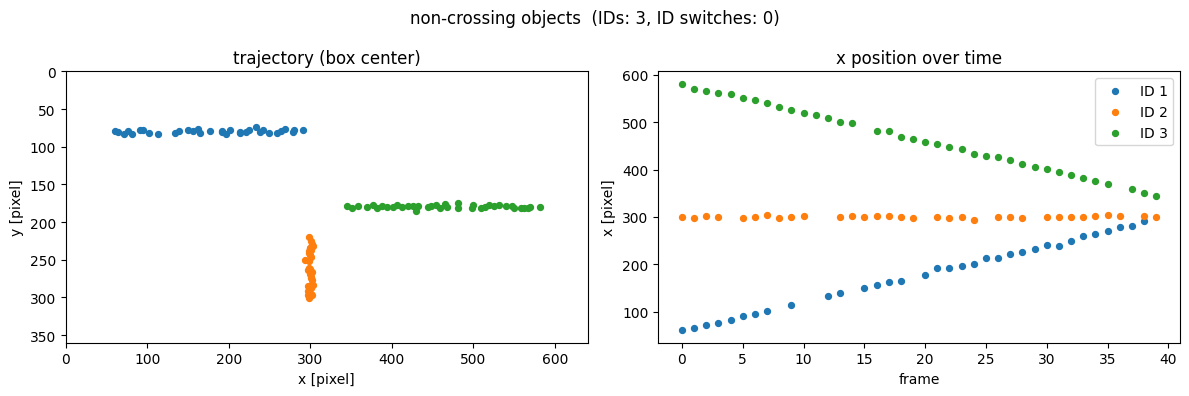

max_age=0 のとき 使われたID: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]  IDスイッチ: 12


In [20]:
# 重ならない3物体の追跡（検出もれあり）
frames_easy = make_detections(
    starts=[(60, 80), (580, 180), (300, 300)],
    velocities=[(6, 0), (-6, 0), (0, -2)],
    miss_prob=0.15, seed=0)
log_easy = run_tracker(frames_easy, IoUTracker(iou_thr=0.3, max_age=5))
print("検出の総数:", len(log_easy), "/", 3 * len(frames_easy))
print("使われたID:", np.unique(log_easy[:, 2]).astype(int))
plot_tracks(log_easy, "non-crossing objects")

# 比較: 見失ったトラックをすぐ消す設定（max_age=0）
log_noage = run_tracker(frames_easy, IoUTracker(iou_thr=0.3, max_age=0))
print("max_age=0 のとき 使われたID:", np.unique(log_noage[:, 2]).astype(int),
      " IDスイッチ:", count_id_switches(log_noage))

結果の読み方
- 点が抜けているフレームが検出もれであり、その前後で色（ID）が変わっていなければ追跡は維持されている
- 3つの物体に対して使われたIDは3つだけであり、IDスイッチは0回である
- `max_age=0` にすると、検出もれのたびにトラックが消えて新しいIDが振られる
  - 物体は3つしかないのに、IDの数はそれよりずっと多くなる
  - 人数を数える応用であれば、そのまま数え間違いになる

追跡の典型的な失敗が、この**IDスイッチ（ID switch）**である
- 同じ物体に別のIDが振り直される、あるいは2つの物体のIDが入れ替わる現象を指す

### IDが入れ替わる例

次に、2つの物体が左右から近づいて**すれ違う**場面を追跡する
- 検出もれは無く、検出器は毎フレーム2つの箱を正しく出力している

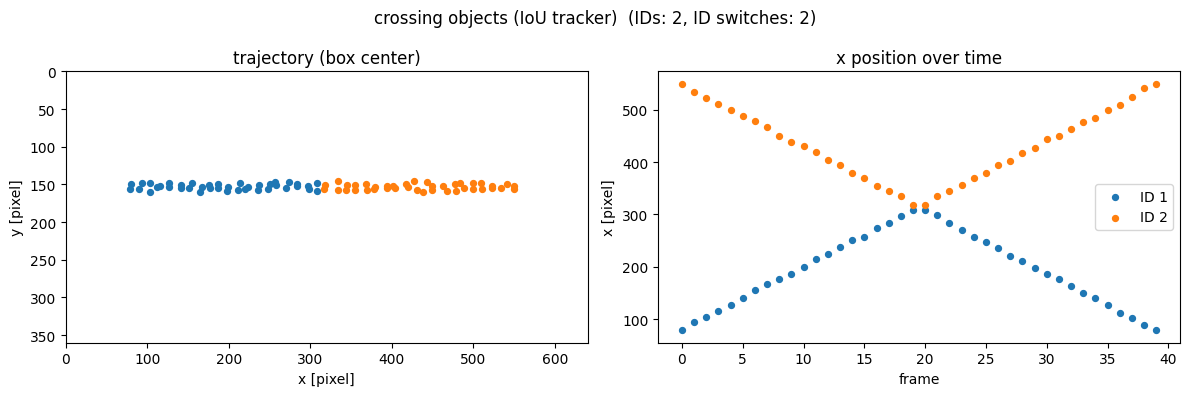

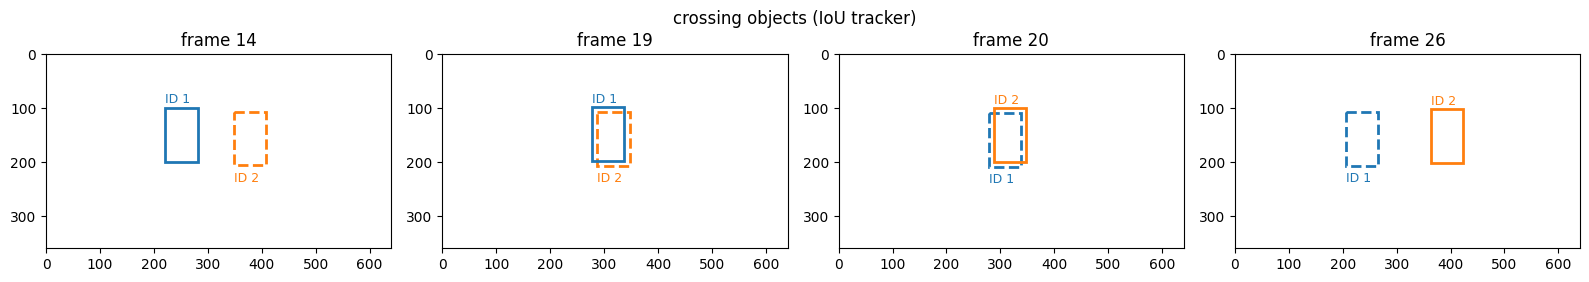

object 0: 1111111111111111111122222222222222222222
object 1: 2222222222222222222211111111111111111111
IDが入れ替わったシードの数: 20 / 20


In [21]:
# すれ違う2物体の追跡
cross_cfg = dict(starts=[(80, 150), (548, 156)], velocities=[(12, 0), (-12, 0)])
frames_cross = make_detections(**cross_cfg, seed=0)
log_cross = run_tracker(frames_cross, IoUTracker(iou_thr=0.3, max_age=5))
plot_tracks(log_cross, "crossing objects (IoU tracker)")
plot_frames(log_cross, [14, 19, 20, 26], "crossing objects (IoU tracker)")

# 正解の物体ごとに、割り当てられたIDの列を表示する
for g in np.unique(log_cross[:, 1]):
    ids = log_cross[log_cross[:, 1] == g][:, 2].astype(int)
    print(f"object {int(g)}:", "".join(str(i) for i in ids))

# 位置のノイズ（乱数シード）を変えて、入れ替わりが起きる回数を数える
n_swap = sum(count_id_switches(run_tracker(make_detections(**cross_cfg, seed=s), IoUTracker())) > 0
             for s in range(20))
print("IDが入れ替わったシードの数:", n_swap, "/ 20")

結果の読み方
- 1枚目の右の図では、2本の直線が交わる点で色が入れ替わり、どちらの物体も「跳ね返った」かのように追跡されている
- 2枚目の図は、色がID、線種が正解の物体（実線が物体0、破線が物体1）である
  - フレーム19までは実線の箱がID 1であるが、フレーム20からは破線の箱がID 1になっている
  - IDは画面の左側に留まり、物体だけが通り抜けていったことになる
- 検出器は一度も間違えていないのに、追跡は失敗している

失敗の理由
- このトラッカーが覚えているのは「最後に観測した箱の位置」だけである
- すれ違う瞬間、物体Aの直前の箱に最も近いのは、反対側から来た物体Bの今の箱である
- ハンガリアン法はIoUの合計を最大にする割当を正しく求めているが、与えた類似度そのものが誤った対応を指している

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-id-switch.png" width=600>

上の図は、すれ違う瞬間の箱の位置関係である
- 上段がトラックの覚えている箱、下段が今のフレームの検出であり、AとBの左右が入れ替わっている
- 同じ位置にある箱どうし（赤い矢印）のIoUが最大となるので、ID 1は物体Bに、ID 2は物体Aに付く

この失敗が起こる条件
- ここでは、2つの物体の中心がフレーム19と20の間で入れ違うように、初期位置と速度を選んである
- このとき入れ替わりは、位置のノイズの乱数によらず起こる（上の出力の「20通り中の回数」を参照）
- 初期位置をずらして、2つの箱がちょうど重なるフレームができるようにすると、どちらの割当もIoUがほぼ等しくなり、入れ替わるかどうかはノイズ次第となる
  - 数値を変えて試す場合は、この点に注意する

人間がこの場面を見て迷わないのは、「右へ動いていた物体は、次も右へ動くはず」と考えるか、「服の色が違う」と見分けるからである
- 前者が動きの予測（カルマンフィルタ）、後者が外見特徴（Re-ID）であり、以降の節で順に扱う

## 追跡の評価指標

対策に進む前に、追跡の良し悪しを数値で測る方法を決めておく
- 物体検出のmAPは1枚ごとの箱の正しさしか見ないので、IDの一貫性は測れない

正解の箱の総数を $\mathrm{GT}$、見逃した正解の箱の数を $\mathrm{FN}$、正解に対応しない出力の箱の数を $\mathrm{FP}$、IDスイッチの回数を $\mathrm{IDSW}$ とする

**MOTA（Multiple Object Tracking Accuracy）**

$$\mathrm{MOTA} = 1 - \frac{\mathrm{FN} + \mathrm{FP} + \mathrm{IDSW}}{\mathrm{GT}}$$

- 3種類の誤りを足して、正解の数で割っただけの単純な指標である
- 通常は $\mathrm{FN}$ と $\mathrm{FP}$ が $\mathrm{IDSW}$ よりも桁違いに多いので、MOTAはほぼ**検出器の性能**で決まる
- IDスイッチは、入れ替わった瞬間の1回しか数えない
  - 入れ替わったまま最後まで追跡しても、誤りは1回分である
  - FPが多いと負の値にもなる

**IDF1**

- 動画全体を通して、正解の軌跡と出力の軌跡（ID）を1対1に対応させる
  - 対応は、一致する箱の数が最大になるように選ぶ（ここでもハンガリアン法を使う）
- 対応した軌跡どうしで一致した箱を $\mathrm{IDTP}$、それ以外の出力の箱を $\mathrm{IDFP}$、それ以外の正解の箱を $\mathrm{IDFN}$ として、F1値を計算する

$$\mathrm{IDF1} = \frac{2\,\mathrm{IDTP}}{2\,\mathrm{IDTP} + \mathrm{IDFP} + \mathrm{IDFN}}$$

- 「同じ物体を、どれだけ長く同じIDで追えたか」を測る指標である
- 途中でIDが入れ替わると、その後の箱はすべて誤り（IDFPかつIDFN）と数えられるので、MOTAよりもIDの一貫性に敏感である

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-mota-vs-idf1.png" width=700>

上の図は、2つの物体を10フレーム追跡し、途中でIDが入れ替わった場合の例である
- MOTAは入れ替わった瞬間の2回だけを誤りとするので、0.90と高い値になる
- IDF1は、入れ替わった後の10個の箱をすべて不一致と数えるので、0.50となる

**HOTA（Higher Order Tracking Accuracy）**

- MOTAは検出に、IDF1は対応付けに偏るので、両方を釣り合わせて1つの数値にする指標である
- 検出の正確さ $\mathrm{DetA}$ と、対応付けの正確さ $\mathrm{AssA}$ を別々に求め、その幾何平均をとる

$$\mathrm{HOTA} = \sqrt{\mathrm{DetA} \cdot \mathrm{AssA}}$$

- $\mathrm{DetA}$ は、箱の単位で数えた $\mathrm{TP} / (\mathrm{TP} + \mathrm{FN} + \mathrm{FP})$ である
- $\mathrm{AssA}$ は、正しく検出できた箱の1つ1つについて、「その箱の出力の軌跡と正解の軌跡が、動画全体でどれだけ一致しているか」を求めて平均したものである
- 幾何平均なので、片方だけが良くても高い値にならない
- 実際には、箱の一致を判定するIoUのしきい値を0.05から0.95まで変えて平均する

本節の合成データでの計算
- 実際の評価では、まず各フレームで出力の箱と正解の箱をIoU（0.5以上など）で対応付けてから、上の数を数える
- 本節の合成データでは、どの検出がどの物体から作られたかがわかっているので、その手間を省いてMOTAとIDF1を直接計算する

In [22]:
# MOTAとIDF1の計算
def mot_metrics(log, n_gt):
    # log: run_tracker の記録  n_gt: 正解の箱の総数（物体数 × フレーム数）
    real = log[log[:, 1] >= 0]                 # 正解の物体に対応する出力
    fn = n_gt - len(real)                      # 出力されなかった正解の箱
    fp = len(log) - len(real)                  # 誤検出がそのまま出力された箱
    idsw = count_id_switches(log)
    # IDF1: 正解の軌跡とIDを1対1に対応させ、一致する箱の数（IDTP）を最大にする
    gts, ids = np.unique(real[:, 1]), np.unique(log[:, 2])
    overlap = np.array([[np.sum((real[:, 1] == g) & (real[:, 2] == i)) for i in ids] for g in gts])
    rows, cols = linear_sum_assignment(-overlap)
    idtp = overlap[rows, cols].sum()
    # IDFN = n_gt - IDTP、IDFP = len(log) - IDTP なので、分母は n_gt + len(log) となる
    return {"FN": fn, "FP": fp, "IDSW": idsw,
            "MOTA": 1 - (fn + fp + idsw) / n_gt, "IDF1": 2 * idtp / (n_gt + len(log))}

def print_metrics(rows):
    # rows: (名前, 記録, 正解の箱の総数) のリスト
    print(f"{'':34s}{'FN':>5s}{'FP':>5s}{'IDSW':>6s}{'MOTA':>8s}{'IDF1':>8s}")
    for name, log, n_gt in rows:
        m = mot_metrics(log, n_gt)
        print(f"{name:34s}{m['FN']:5d}{m['FP']:5d}{m['IDSW']:6d}{m['MOTA']:8.3f}{m['IDF1']:8.3f}")

print_metrics([("non-crossing, max_age=5", log_easy, 3 * len(frames_easy)),
               ("non-crossing, max_age=0", log_noage, 3 * len(frames_easy)),
               ("crossing, IoU tracker", log_cross, 2 * len(frames_cross))])

                                     FN   FP  IDSW    MOTA    IDF1
non-crossing, max_age=5              15    0     0   0.875   0.933
non-crossing, max_age=0              15    0    12   0.775   0.409
crossing, IoU tracker                 0    0     2   0.975   0.500


結果の読み方
- 1行目: 追跡器は一度も間違えていないが、MOTAは1にならない
  - 検出もれ（FN）がそのまま減点されるためであり、MOTAが検出器の性能に左右されることがわかる
  - IDF1も、見逃した箱の分だけ下がる
- 2行目: `max_age=0` では、同じ検出結果に対してIDスイッチが増え、IDF1が大きく下がる
  - 1つの物体の軌跡が細切れになり、正解の軌跡と対応できるのはそのうちの1本だけだからである
- 3行目: すれ違いでは、IDスイッチは2回だけなのでMOTAはほとんど下がらない
  - 一方でIDF1は約0.5となる
  - 後半の箱がすべて別の物体のIDで出力されており、動線の解析には使えないことを、IDF1は正しく表している

用途によって見るべき指標は異なる
- ある瞬間の人数や混雑度を知りたいなら、検出の正しさが重要でありMOTAが目安になる
- 個々の物体の動線を知りたいなら、IDの一貫性が重要でありIDF1やHOTAを見る

## カルマンフィルタによる予測

IoUだけの対応付けは、すれ違いのほかにも、物体が速く動く場合や数フレーム検出が途切れた場合に弱い
- 前に観測した箱と今の箱が重ならなくなるためである

そこで、物体の**動き**を推定し、「今のフレームではここにいるはず」という予測と検出とを対応付ける
- この推定に広く使われるのが**カルマンフィルタ（Kalman filter）**であり、SORT（Simple Online and Realtime Tracking）以降の追跡器の標準的な部品となっている

### 状態と観測

カルマンフィルタは、2種類の量を区別する
- **状態（state）** $\mathbf{x}$: 知りたい量であり、直接は見えないものを含む
  - 例: 物体の位置 $p$ と速度 $v$ を並べた $\mathbf{x} = (p, v)^\top$
- **観測（observation）** $\mathbf{z}$: センサで得られる量であり、誤差を含む
  - 例: 検出器が出力した位置（速度は観測できない）

そして、2つのモデルを仮定する
- 運動モデル: $\mathbf{x}_t = F \mathbf{x}_{t-1} + \mathbf{w}$
  - 等速運動なら $p_t = p_{t-1} + v_{t-1}$、$v_t = v_{t-1}$ なので、$F = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$
  - $\mathbf{w}$ は、等速という仮定からのずれ（加減速）を表す雑音であり、共分散を $Q$ とする
- 観測モデル: $\mathbf{z}_t = H \mathbf{x}_t + \mathbf{v}$
  - 位置だけを観測するなら $H = \begin{pmatrix} 1 & 0 \end{pmatrix}$
  - $\mathbf{v}$ は観測の誤差であり、共分散を $R$ とする

カルマンフィルタは、状態の推定値 $\hat{\mathbf{x}}$ とともに、その**不確かさ**を表す共分散行列 $P$ を持ち続ける

### 予測と更新

毎フレーム、次の2段階を繰り返す

**予測（predict）**: 運動モデルで状態を1フレーム進める

$$\hat{\mathbf{x}} \leftarrow F \hat{\mathbf{x}}, \qquad P \leftarrow F P F^\top + Q$$

- 観測なしに先へ進めるので、不確かさ $P$ は大きくなる

**更新（update）**: 観測 $\mathbf{z}$ で予測を修正する

$$K = P H^\top (H P H^\top + R)^{-1}$$
$$\hat{\mathbf{x}} \leftarrow \hat{\mathbf{x}} + K(\mathbf{z} - H \hat{\mathbf{x}}), \qquad P \leftarrow (I - K H) P$$

- $\mathbf{z} - H\hat{\mathbf{x}}$ は、観測と予測の食い違いである
- $K$ は**カルマンゲイン（Kalman gain）**であり、食い違いのうちどれだけを状態の修正に使うかを決める
  - 予測の不確かさ $P$ が観測の誤差 $R$ より大きいときは $K$ が大きくなり、観測を信用する
  - 逆のときは $K$ が小さくなり、予測を信用する
- 観測を取り込んだので、不確かさ $P$ は小さくなる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-kalman-fusion.png" width=550>

上の図は、更新が行っていることを1次元の分布で描いたものである
- 予測（青）と観測（緑）は、どちらも不確かさを持つ分布である
- 更新後の推定（橙）は、不確かさの小さい側に寄った位置にあり、その幅はどちらの分布よりも狭い

- 位置しか観測していないのに速度も修正されるのは、$P$ の非対角成分が「位置と速度の誤差の相関」を保持しているからである

観測が得られなかったフレームでは、予測だけを行い更新を飛ばせばよい
- これが、検出もれや遮蔽の間も物体の位置を追い続けられる理由である

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-kalman-cycle.png" width=700>

上の図は、予測と更新の循環をまとめたものである
- 予測で不確かさが増え、更新で不確かさが減ることを、フレームごとに繰り返す

### 1次元の例

まず1次元で実装し、動作を確かめる
- 速度2で等速に動く物体の位置を、標準偏差5の誤差がある観測から推定する
- 途中の10フレームは観測が得られないものとする

観測の誤差 (RMSE): 4.89
推定の誤差 (RMSE): 3.12
観測が無い区間の終わり(t=39)での推定の誤差: 0.23


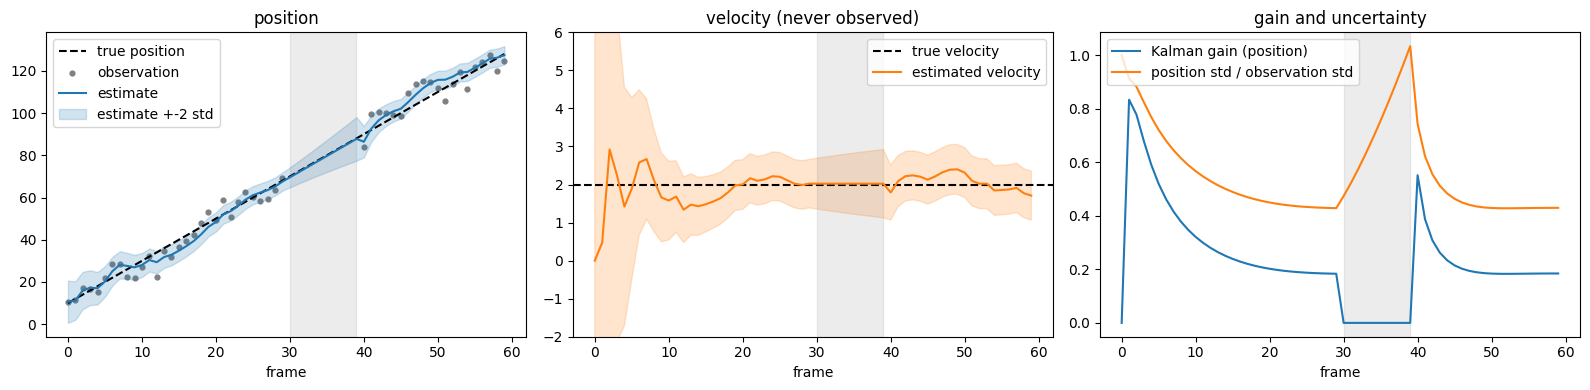

In [23]:
# カルマンフィルタの予測と更新（状態の次元によらず使える形で書く）
def kf_predict(x, P, F, Q):
    return F @ x, F @ P @ F.T + Q

def kf_update(x, P, z, H, R):
    S = H @ P @ H.T + R                    # 観測と予測の食い違いの共分散
    K = P @ H.T @ np.linalg.inv(S)         # カルマンゲイン
    x = x + K @ (z - H @ x)
    P = (np.eye(len(x)) - K @ H) @ P
    return x, P, K

# 1次元の等速運動: 状態は (位置, 速度)、観測は位置のみ
rng = np.random.default_rng(0)
T, obs_std = 60, 5.0
true_pos = 10 + 2.0 * np.arange(T)
z_all = true_pos + rng.normal(0, obs_std, T)
gap = range(30, 40)                        # 観測が得られないフレーム

F = np.array([[1.0, 1.0], [0.0, 1.0]])
H = np.array([[1.0, 0.0]])
Q = np.diag([0.01, 0.01])                  # 等速の仮定からのずれは小さいとする
R = np.array([[obs_std ** 2]])

x = np.array([z_all[0], 0.0])              # 初期値: 位置は最初の観測、速度は不明なので0
P = np.diag([obs_std ** 2, 100.0])         # 速度は不明なので不確かさを大きくしておく
est, std, gain = [x.copy()], [np.sqrt(np.diag(P))], [np.zeros(2)]
for t in range(1, T):
    x, P = kf_predict(x, P, F, Q)
    k = np.zeros(2)
    if t not in gap:
        x, P, K = kf_update(x, P, z_all[t:t + 1], H, R)
        k = K[:, 0]
    est.append(x.copy()); std.append(np.sqrt(np.diag(P))); gain.append(k)
est, std, gain = np.array(est), np.array(std), np.array(gain)

seen = np.array([t not in gap for t in range(T)])
late = seen & (np.arange(T) >= 10)         # 推定が落ち着いた後の、観測があるフレーム
print("観測の誤差 (RMSE):", round(float(np.sqrt(np.mean((z_all[late] - true_pos[late]) ** 2))), 2))
print("推定の誤差 (RMSE):", round(float(np.sqrt(np.mean((est[late, 0] - true_pos[late]) ** 2))), 2))
print("観測が無い区間の終わり(t=39)での推定の誤差:", round(float(abs(est[39, 0] - true_pos[39])), 2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ts = np.arange(T)
axes[0].plot(ts, true_pos, "k--", label="true position")
axes[0].scatter(ts[seen], z_all[seen], s=12, color="gray", label="observation")
axes[0].plot(ts, est[:, 0], color="tab:blue", label="estimate")
axes[0].fill_between(ts, est[:, 0] - 2 * std[:, 0], est[:, 0] + 2 * std[:, 0], color="tab:blue", alpha=0.2, label="estimate +-2 std")
axes[0].set_title("position"); axes[0].set_xlabel("frame"); axes[0].legend()
axes[1].axhline(2.0, color="k", linestyle="--", label="true velocity")
axes[1].plot(ts, est[:, 1], color="tab:orange", label="estimated velocity")
axes[1].fill_between(ts, est[:, 1] - 2 * std[:, 1], est[:, 1] + 2 * std[:, 1], color="tab:orange", alpha=0.2)
axes[1].set_ylim(-2, 6)
axes[1].set_title("velocity (never observed)"); axes[1].set_xlabel("frame"); axes[1].legend()
axes[2].plot(ts, gain[:, 0], label="Kalman gain (position)")
axes[2].plot(ts, std[:, 0] / obs_std, label="position std / observation std")
axes[2].set_title("gain and uncertainty"); axes[2].set_xlabel("frame"); axes[2].legend()
for ax in axes:
    ax.axvspan(gap[0], gap[-1], color="gray", alpha=0.15)
plt.tight_layout()
plt.show()

結果の読み方（灰色の帯が、観測の無い区間である）
- 左: 推定（青線）は、ばらつく観測（灰色の点）よりも真の位置（破線）に近い
  - 出力のRMSEを比べると、推定の誤差は観測の誤差より小さい
  - 過去の観測をすべて運動モデルを通して使っているためである
- 中央: 速度は一度も観測していないが、位置の観測の変化から推定され、10フレームほどで真の値2の付近に落ち着く
  - 橙の帯（不確かさ）も、初めは非常に広く、観測を重ねるごとに狭くなる
- 右: カルマンゲインは、最初は大きく（観測を信用する）、推定が定まるにつれて小さくなる（予測を信用する）
- 観測の無い区間
  - 推定は、それまでに得た速度でそのまま進み続ける
  - 不確かさ（青い帯の幅、右の図の橙線）は、フレームごとに大きくなる
  - 観測が戻った直後はゲインが大きくなり、観測を強く取り込んで不確かさが一気に下がる

$Q$ と $R$ は設計者が決める値である
- $Q$ を大きくすると「物体は急に動きを変えうる」と仮定することになり、観測への追従は速くなるが推定はばらつく
- $R$ を大きくすると「観測は信用できない」と仮定することになり、推定は滑らかになるが動きの変化への反応は遅れる

### カルマンフィルタを組み込んだトラッカー

これを追跡に使う
- 各トラックが1つのカルマンフィルタを持つ
  - 状態は、箱の中心と速度の4次元 $(c_x, c_y, v_x, v_y)$ とする
  - 観測は、検出された箱の中心 $(c_x, c_y)$ である
  - 箱の幅と高さは、最後に観測した値をそのまま使う
    - SORTでは箱の面積と縦横比も状態に含めて推定するが、ここでは簡単のために省く
- 毎フレーム、まず全てのトラックを**予測**で1フレーム進める
- 対応付けは、**予測した箱**と検出の箱のIoUで行う
- 対応が付いたトラックは、その検出で**更新**する
- 対応が付かなかったトラックは更新せず、予測だけで動かし続ける

後でByteTrackに拡張するので、対応付け、見失ったトラックの処理、新しいトラックの作成を、それぞれメソッドに分けておく

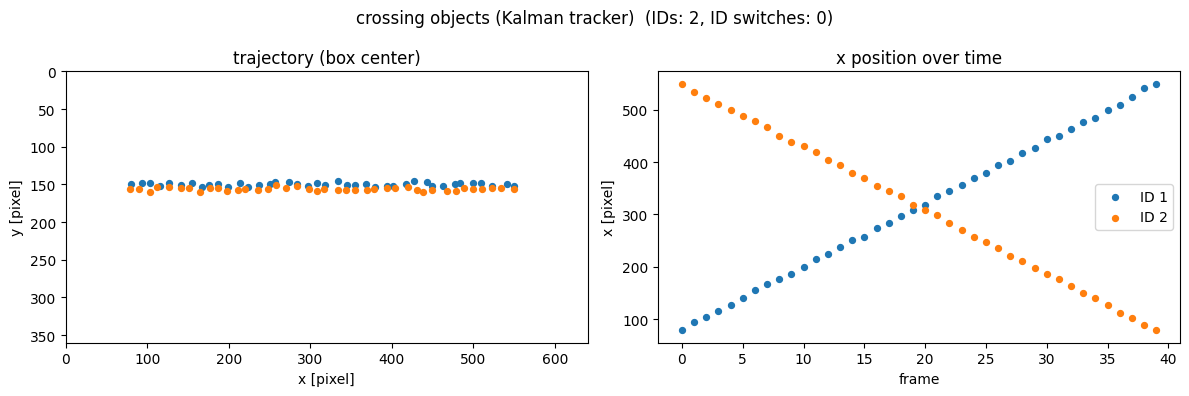

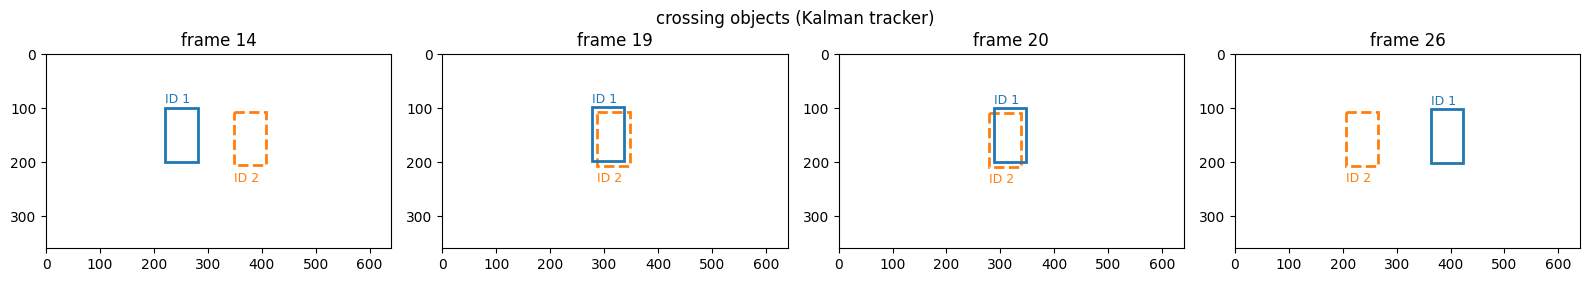

                                     FN   FP  IDSW    MOTA    IDF1
crossing, IoU tracker                 0    0     2   0.975   0.500
crossing, Kalman tracker              0    0     0   1.000   1.000
crossing + 30% miss, IoU tracker     17    0     5   0.725   0.336
crossing + 30% miss, Kalman          17    0     0   0.787   0.881


In [24]:
# カルマンフィルタで箱の位置を予測するトラッカー
class KalmanTracker:
    F = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], dtype=float)  # 等速運動
    H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], dtype=float)                              # 中心だけを観測

    def __init__(self, iou_thr=0.3, max_age=5, q=0.05, r=4.0):
        self.iou_thr, self.max_age = iou_thr, max_age
        self.Q, self.R = q * np.eye(4), r * np.eye(2)
        self.tracks = {}   # ID -> {"x": 状態, "P": 共分散, "size": 箱の幅と高さ, "age": 見失ってからのフレーム数}
        self.next_id = 1

    def _box(self, tr):
        # トラックの現在の状態から箱を作る
        c, half = tr["x"][:2], tr["size"] / 2
        return np.concatenate([c - half, c + half])

    def _predict(self):
        # 全てのトラックを1フレーム進める
        for tr in self.tracks.values():
            tr["x"], tr["P"] = kf_predict(tr["x"], tr["P"], self.F, self.Q)

    def _match(self, ids, dets, cand, assigned):
        # トラック ids と、検出のうち番号が cand のものとを対応付け、対応が付いたトラックを更新する
        # 戻り値: 対応が付かなかったトラックのIDのリスト
        if not ids or not len(cand):
            return ids
        pred = np.array([self._box(self.tracks[i]) for i in ids])
        pairs = associate(iou_matrix(pred, dets[cand]), self.iou_thr)
        for r, c in pairs:
            tr, box = self.tracks[ids[r]], dets[cand[c]]
            tr["x"], tr["P"], _ = kf_update(tr["x"], tr["P"], (box[:2] + box[2:]) / 2, self.H, self.R)
            tr["size"], tr["age"] = box[2:] - box[:2], 0
            assigned[cand[c]] = ids[r]
        matched = {ids[r] for r, _ in pairs}
        return [i for i in ids if i not in matched]

    def _age(self, ids):
        # 対応が付かなかったトラック: ageを増やし、max_ageを超えたら削除する
        for i in ids:
            self.tracks[i]["age"] += 1
            if self.tracks[i]["age"] > self.max_age:
                del self.tracks[i]

    def _new(self, dets, cand, assigned):
        # 対応が付かなかった検出から、新しいトラックを作る（速度は不明なので0、不確かさは大きく）
        for c in cand:
            if assigned[c] < 0:
                box = dets[c]
                self.tracks[self.next_id] = {
                    "x": np.concatenate([(box[:2] + box[2:]) / 2, [0.0, 0.0]]),
                    "P": np.diag([self.R[0, 0], self.R[1, 1], 100.0, 100.0]),
                    "size": box[2:] - box[:2], "age": 0}
                assigned[c] = self.next_id
                self.next_id += 1

    def update(self, dets):
        self._predict()
        assigned = np.full(len(dets), -1)
        cand = np.arange(len(dets))
        lost = self._match(list(self.tracks), dets, cand, assigned)
        self._age(lost)
        self._new(dets, cand, assigned)
        return assigned

# すれ違う2物体: IoUトラッカーと比較する
log_cross_kf = run_tracker(frames_cross, KalmanTracker())
plot_tracks(log_cross_kf, "crossing objects (Kalman tracker)")
plot_frames(log_cross_kf, [14, 19, 20, 26], "crossing objects (Kalman tracker)")

# 検出もれを30%に増やした場合も比較する
frames_cross_miss = make_detections(**cross_cfg, miss_prob=0.3, seed=0)
n_gt = 2 * len(frames_cross)
print_metrics([
    ("crossing, IoU tracker", log_cross, n_gt),
    ("crossing, Kalman tracker", log_cross_kf, n_gt),
    ("crossing + 30% miss, IoU tracker", run_tracker(frames_cross_miss, IoUTracker()), n_gt),
    ("crossing + 30% miss, Kalman", run_tracker(frames_cross_miss, KalmanTracker()), n_gt)])

結果の読み方
- カルマンフィルタを入れると、すれ違いの前後でIDが維持され、2本の直線がそれぞれ1色のまま交差する
  - 2枚目の図では、実線の箱（物体0）が最後までID 1のままであり、IDが物体と一緒に右へ通り抜けている
- 検出もれを30%に増やすと、IoUトラッカーではIDスイッチがさらに増える
  - 見失っている間に物体が進み、戻ってきた箱が最後に観測した箱と重ならなくなるためである
  - この例の物体は1フレームに12ピクセル動くので、幅60の箱は数フレームで重なりを失う
- カルマントラッカーは、見失っている間も予測で箱を動かし続けるので、戻ってきた検出と重なり、IDが維持される
  - 検出もれによるFNは追跡器では減らせないので、MOTAの差はIDスイッチの回数の分だけであり小さい
  - 大きな差が現れるのはIDF1であり、評価指標を使い分ける必要があることがここでもわかる

カルマンフィルタの限界
- 等速運動の仮定から外れる動き（急な方向転換、急停止）では予測が外れる
- カメラ自体が動くと、画像上の物体の動きは等速でなくなる
  - BoT-SORTなどは、背景の動きからカメラの動きを推定して補正する
- 長い遮蔽の後では予測の不確かさが大きくなり、位置だけでは同じ物体かどうかを判断できない

## 外見特徴（Re-ID）を使う対応付け

位置と動きだけでは区別できない場面で使えるもう1つの手がかりが、**見た目**である
- 服の色や体格が違えば、すれ違っても、長く隠れた後でも、同じ人物かどうかを判断できる

**Re-ID（Re-Identification、再同定）**
- 箱で切り出した画像を、別のネットワーク（Re-IDモデル）に入力し、数百次元程度の**特徴ベクトル（埋め込み）**に変換する
- このネットワークは、「同じ人物の画像は近く、別の人物の画像は遠く」なるように学習されている
  - 距離学習（metric learning）と呼ばれる学習方法であり、顔認証と同じ考え方である
- 2つの箱の外見の類似度は、特徴ベクトルのコサイン類似度で測る

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-reid.png" width=750>

上の図は、外見特徴を使う対応付けの流れである
- トラックと検出の切り出し画像を同じRe-IDモデルに通し、得られた特徴ベクトルどうしの類似度を求める
- これを位置の類似度（IoU）と重み付きで合成し、対応付けに使う

**DeepSORT**は、SORTにこの外見特徴を加えた追跡器である
- 各トラックは、過去に観測した特徴ベクトルを保持する
- 対応付けのコストに、位置（カルマンフィルタの予測との距離）と外見（特徴ベクトルの距離）の両方を使う
- 見失ってからの時間が短いトラックを優先して対応付ける
- 外見は位置と違って時間が経っても大きく変わらないので、`max_age` を長くとって長い遮蔽からの復帰を狙える

代償もある
- 箱ごとにネットワークを1回実行するので、物体が多いと計算時間が増える
- 同じ制服を着た人々や同じ車種の車のように、見た目が似た物体は区別できない
- 向きや照明が変わると、同じ物体でも特徴が変わる
  - 特徴ベクトルを指数移動平均でなめらかに更新するなどの工夫が使われる

ここではRe-IDモデルの学習は行わず、すれ違いの瞬間の類似度行列を見て、外見特徴がどう効くかを確かめる
- 2つの物体にランダムな単位ベクトルを割り当て、これを「真の外見」とする
- 観測のたびに雑音が加わった特徴ベクトルが得られるものとする

In [25]:
# すれ違いの瞬間の類似度行列: IoU、外見、両者の組合せ
rng = np.random.default_rng(0)

def unit(v):
    return v / np.linalg.norm(v, axis=-1, keepdims=True)

appearance = unit(rng.normal(size=(2, 64)))          # 2物体の真の外見（本来はRe-IDモデルの出力）
def observe_feature():
    return unit(appearance + rng.normal(0, 0.08, appearance.shape))   # 観測のたびに少し変わる

def sorted_boxes(frame):
    boxes, gt = frame
    return boxes[np.argsort(gt)]                     # 正解の物体番号の順に並べ直す

prev_boxes, now_boxes = sorted_boxes(frames_cross[19]), sorted_boxes(frames_cross[20])
iou_sim = iou_matrix(prev_boxes, now_boxes)          # 行: フレーム19のトラック 列: フレーム20の検出
app_sim = observe_feature() @ observe_feature().T    # コサイン類似度
np.set_printoptions(precision=2, suppress=True)
for name, sim in [("IoU", iou_sim), ("appearance", app_sim),
                  ("0.5*IoU + 0.5*appearance", 0.5 * iou_sim + 0.5 * app_sim)]:
    pairs = associate(sim, thr=0.3)
    print(f"--- {name}\n{sim}\n割当 (トラック, 検出): {[(int(r), int(c)) for r, c in pairs]}")

--- IoU
[[0.68 0.79]
 [0.87 0.73]]
割当 (トラック, 検出): [(0, 1), (1, 0)]
--- appearance
[[ 0.71 -0.17]
 [-0.09  0.7 ]]
割当 (トラック, 検出): [(0, 0), (1, 1)]
--- 0.5*IoU + 0.5*appearance
[[0.7  0.31]
 [0.39 0.71]]
割当 (トラック, 検出): [(0, 0), (1, 1)]


結果の読み方（行と列は正解の物体番号の順なので、対角の `(0, 0), (1, 1)` が正しい割当である）
- IoUだけの行列は、非対角のほうが大きく、割当は `(0, 1), (1, 0)` と入れ替わる
- 外見の行列は、対角が大きく（約0.7）、非対角は0付近である
  - 同じ物体でも観測のたびに雑音が加わるので、類似度は1にはならない
  - 64次元のランダムなベクトルどうしはほぼ直交するので、別の物体との類似度は0付近になる
- 両者を足した行列では、外見の差がIoUの差を上回り、正しい割当が選ばれる

実際のRe-IDモデルでは、別人どうしの類似度がここまで低くなることはなく、位置と外見の重みの決め方が性能を左右する

## ByteTrack: 低スコアの検出を捨てない

IDスイッチのもう1つの原因は、検出器の**スコアによる足切り**である
- 通常は、スコアが低い検出（例えば0.5未満）を捨ててから追跡器に渡す
  - 背景を誤って検出したものの多くは、スコアが低いからである
- しかし、他の物体に隠れかけた物体も、スコアが下がるだけで検出自体はされていることが多い
- これを捨てるとトラックが途切れ、再び現れたときに別のIDが付いてしまう
- かといって、しきい値を下げて全部を追跡器に渡すと、今度は誤検出にIDが付く

**ByteTrack**は、検出をスコアで2つに分け、対応付けを2回行う
1. 全てのトラックをカルマンフィルタで予測する
2. 1回目: **高スコアの検出**とトラックを対応付ける
3. 2回目: 1回目で対応が付かなかったトラックと、**低スコアの検出**を対応付ける
4. どちらでも対応が付かなかったトラックは、見失ったものとして `max_age` まで残す
5. 対応が付かなかった高スコアの検出から、新しいトラックを作る
6. 対応が付かなかった低スコアの検出は捨てる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/track-bytetrack.png" width=750>

上の図は、この手順を流れとして描いたものである
- 左が入力、中央が2回の対応付け、右がそれぞれの結果の扱いである
- 低スコアの検出（破線の箱）は、2回目の対応付けにだけ使われる

なぜこれでうまくいくのか
- 低スコアの検出のうち、既存のトラックの予測位置に重なるものは、「隠れかけた本物の物体」である可能性が高い
- 背景の誤検出は、たまたまトラックの予測位置に重ならない限り、2回目の対応付けで相手が見つからずに捨てられる
- 低スコアの検出からは新しいトラックを作らないので、誤検出にIDが付くこともない
- つまり、「追跡中の物体がそこにいるはず」という時間方向の情報を使って、スコアだけでは区別できない本物と誤検出を見分けている

これを、先の `KalmanTracker` を継承して実装する
- 合成データにはスコアを付ける
  - 通常の検出は高スコア、ある物体が隠れかけている区間だけ低スコアとする
  - さらに、毎フレーム2個の低スコアの誤検出をランダムな位置に加える

                                     FN   FP  IDSW    MOTA    IDF1
Kalman, score >= 0.5 only            12    0     1   0.892   0.842
Kalman, score >= 0.1 (all)            0   80     0   0.333   0.750
ByteTrack (0.5 / 0.1)                 0    0     0   1.000   1.000


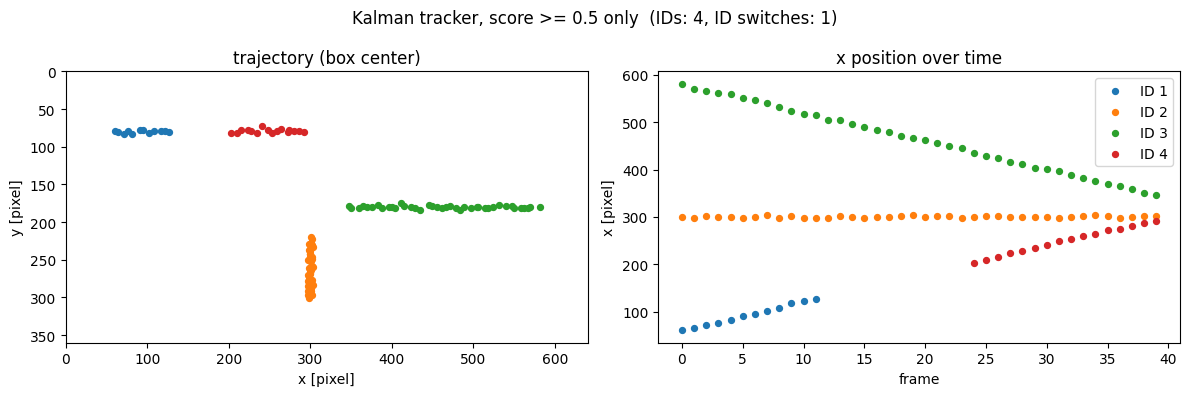

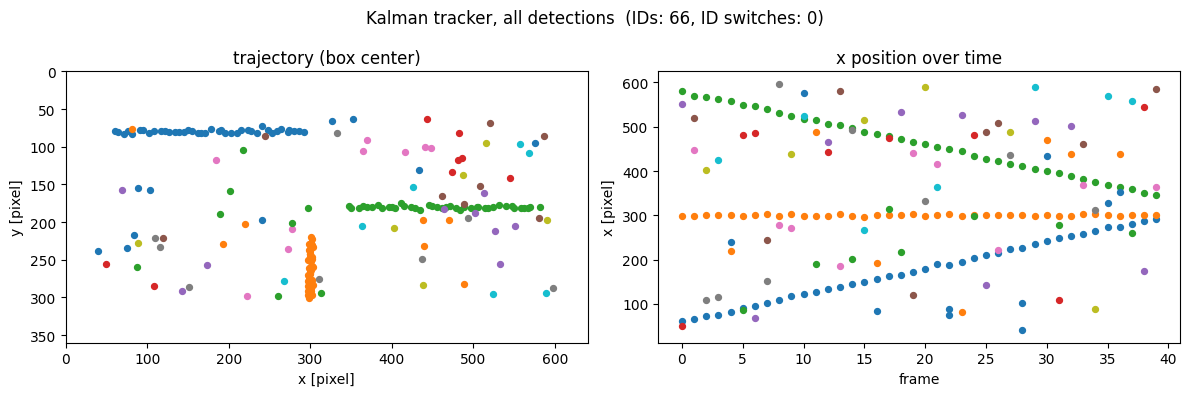

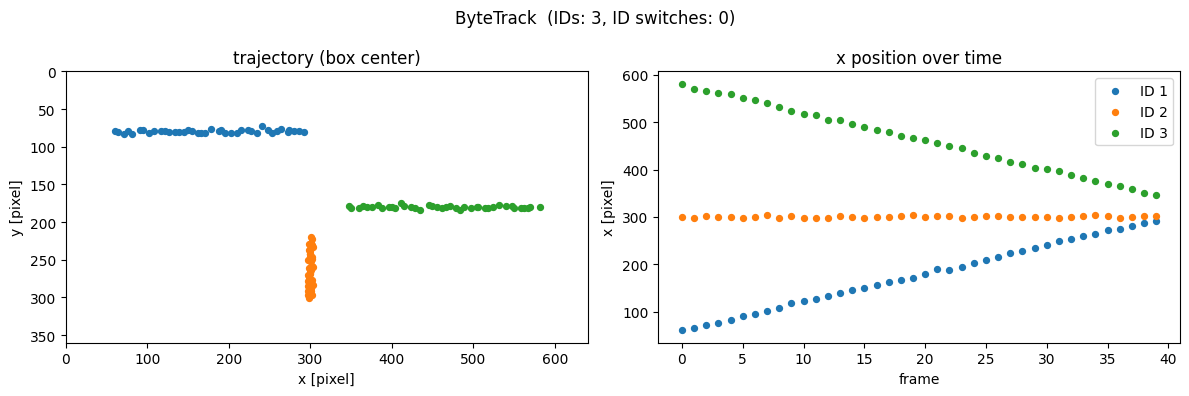

In [26]:
# スコア付きの合成データと、ByteTrackの2段階の対応付け
def add_scores(frames, occluded, fp_per_frame=2, size=(60, 100), seed=0):
    # frames: make_detections の出力  occluded: {物体番号: (開始フレーム, 終了フレーム)} この区間はスコアが下がる
    # 戻り値: フレームごとの (箱, 正解の物体番号, スコア) 誤検出の正解番号は-1とする
    rng = np.random.default_rng(seed)
    half = np.array(size) / 2
    out = []
    for t, (boxes, gt) in enumerate(frames):
        scores = rng.uniform(0.6, 0.95, len(gt))
        for k, g in enumerate(gt):
            if g in occluded and occluded[g][0] <= t < occluded[g][1]:
                scores[k] = rng.uniform(0.15, 0.45)
        centers = rng.uniform([40, 60], [600, 300], (fp_per_frame, 2))   # 誤検出の位置
        out.append((np.vstack([boxes, np.hstack([centers - half, centers + half])]),
                    np.concatenate([gt, -np.ones(fp_per_frame, dtype=int)]),
                    np.concatenate([scores, rng.uniform(0.1, 0.45, fp_per_frame)])))
    return out

class ByteTracker(KalmanTracker):
    def __init__(self, high_thr=0.5, low_thr=0.1, **kwargs):
        super().__init__(**kwargs)
        self.high_thr, self.low_thr = high_thr, low_thr

    def update(self, dets, scores):
        self._predict()
        assigned = np.full(len(dets), -1)
        high = np.flatnonzero(scores >= self.high_thr)
        low = np.flatnonzero((scores >= self.low_thr) & (scores < self.high_thr))
        lost = self._match(list(self.tracks), dets, high, assigned)   # 1回目: 高スコアの検出
        lost = self._match(lost, dets, low, assigned)                 # 2回目: 残ったトラックと低スコアの検出
        self._age(lost)
        self._new(dets, high, assigned)                               # 新しいトラックは高スコアの検出からのみ
        return assigned                                               # 対応が付かなかった低スコアの検出は-1のまま

class ScoreFilter:
    # 比較用: スコアが thr 以上の検出だけを、スコアを使わないトラッカーに渡す
    def __init__(self, tracker, thr):
        self.tracker, self.thr = tracker, thr

    def update(self, dets, scores):
        keep = scores >= self.thr
        assigned = np.full(len(dets), -1)
        assigned[keep] = self.tracker.update(dets[keep])
        return assigned

# 3物体のうち物体0が、フレーム12から23まで隠れかけてスコアが下がる
frames_clean = make_detections(
    starts=[(60, 80), (580, 180), (300, 300)],
    velocities=[(6, 0), (-6, 0), (0, -2)], seed=0)
frames_scored = add_scores(frames_clean, occluded={0: (12, 24)})

log_high = run_tracker(frames_scored, ScoreFilter(KalmanTracker(), 0.5))
log_all = run_tracker(frames_scored, ScoreFilter(KalmanTracker(), 0.1))
log_byte = run_tracker(frames_scored, ByteTracker())
n_gt = 3 * len(frames_scored)
print_metrics([("Kalman, score >= 0.5 only", log_high, n_gt),
               ("Kalman, score >= 0.1 (all)", log_all, n_gt),
               ("ByteTrack (0.5 / 0.1)", log_byte, n_gt)])
plot_tracks(log_high, "Kalman tracker, score >= 0.5 only")
plot_tracks(log_all, "Kalman tracker, all detections")
plot_tracks(log_byte, "ByteTrack")

結果の読み方
- スコア0.5以上だけを使う場合（1枚目）
  - 物体0（上を右へ動く物体）は、スコアが下がった12フレームの間、追跡器から見えなくなる
  - `max_age=5` を超えるのでトラックは削除され、再び現れたときに新しいIDが振られる
  - 見えなかった12個の箱がFNとなり、IDスイッチも1回起こる
- 全ての検出を使う場合（2枚目）
  - 物体0は途切れないが、毎フレーム2個の誤検出のすべてにIDが付いて出力される
  - 正解の箱120個に対してFPが80個となり、MOTAは大きく下がる
  - IDスイッチは0回であるが、出力の4割が誤検出なのでIDF1も下がる
- ByteTrack（3枚目）
  - 物体0は、スコアが下がっている間も2回目の対応付けで拾われ、同じIDのまま追跡される
  - 誤検出は、追跡中のトラックの予測位置にたまたま重ならない限り出力されず、この例では1つも出力されていない
  - FN、FP、IDスイッチのすべてが0となり、MOTAとIDF1はともに1である

追跡器は、検出器の出力をただ受け取るだけでなく、時間方向の情報を使って検出器の弱点を補えることがわかる

## Ultralyticsによる実動画の追跡

実際の動画で追跡を試す
- 本章のYOLOv3は学習の仕組みを理解するための実装なので、ここではUltralytics社のライブラリと学習済みモデル（YOLO11n）を使う
- `model.track()` は、検出と追跡をまとめて行う関数であり、追跡器としてByteTrackとBoT-SORTを選べる
  - ここで使われるByteTrackは、カルマンフィルタの状態に箱の大きさを含めるなど、自作したものより作り込まれているが、骨組みは同じである

In [27]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.0 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 287ms
Prepared 1 package in 54ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

フレーム数: 62  付与されたIDの数: 24


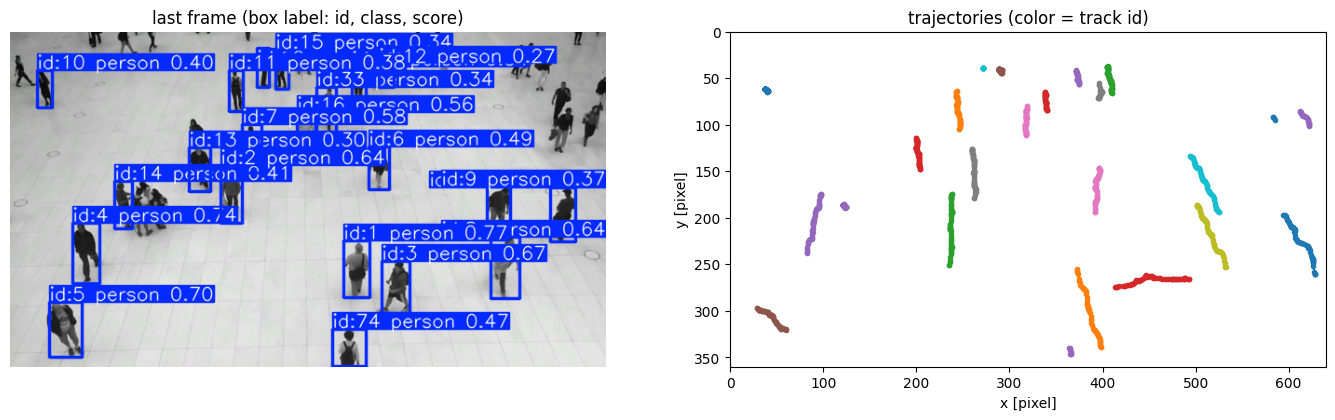

In [28]:
# 学習済みYOLO11nとByteTrackで動画を追跡する
import urllib.request
from ultralytics import YOLO

# 動画はUltralyticsが公開している短いサンプル（640x360、約2秒）
video_url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/solutions_ci_demo.mp4"
urllib.request.urlretrieve(video_url, "sample.mp4")

det_model = YOLO("yolo11n.pt")
history = {}       # ID -> [(フレーム番号, 中心x, 中心y), ...]
last_frame = None
# stream=True とすると、フレームごとに結果を順に受け取れる
for t, r in enumerate(det_model.track("sample.mp4", tracker="bytetrack.yaml",
                                      stream=True, verbose=False)):
    last_frame = r.plot()                 # 箱とIDを描いた画像（BGR）
    if r.boxes.id is None:                # 追跡中の物体が無いフレーム
        continue
    for i, (cx, cy, w, h) in zip(r.boxes.id.int().tolist(), r.boxes.xywh.cpu().numpy()):
        history.setdefault(i, []).append((t, cx, cy))

print("フレーム数:", t + 1, " 付与されたIDの数:", len(history))

# 左: 最後のフレームの追跡結果 右: IDごとの中心の軌跡
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(last_frame[:, :, ::-1])
axes[0].axis("off")
axes[0].set_title("last frame (box label: id, class, score)")
for i, pts in history.items():
    pts = np.array(pts)
    axes[1].plot(pts[:, 1], pts[:, 2], ".-", color=plt.cm.tab10(i % 10))
axes[1].set_xlim(0, last_frame.shape[1]); axes[1].set_ylim(last_frame.shape[0], 0)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x [pixel]"); axes[1].set_ylabel("y [pixel]")
axes[1].set_title("trajectories (color = track id)")
plt.tight_layout()
plt.show()

結果の読み方
- 左の画像では、箱のラベルの先頭に `id:番号` が付いており、これが追跡器の付けたIDである
- 右の図は、IDごとに中心の座標をつないだものであり、1本の線が1つの物体の動線に対応する
  - 線が途中で切れて別の色で続いている箇所があれば、そこでIDが振り直されている
- IDの番号は連番にならない
  - 追跡器の内部では、すぐに消えた検出にも番号が消費されるためであり、番号の最大値は物体の数を表さない

`tracker="botsort.yaml"` に変えると、追跡器をBoT-SORTに切り替えられる
- 追跡器の設定（スコアのしきい値、トラックを残すフレーム数など）は、このYAMLファイルに書かれている
- 自作のトラッカーの `high_thr`、`low_thr`、`iou_thr`、`max_age` に相当する項目があるので、対応を確認するとよい
- BoT-SORTは、設定によりRe-IDの外見特徴も利用できる

# 姿勢推定（Pose Estimation）

物体検出が「人がどこにいるか」を箱で答えるのに対し、**姿勢推定**は「その人の関節がどこにあるか」を答える
- 肩、肘、手首、腰、膝、足首などの決められた点（**キーポイント**、keypoint）の座標を推定するので、**キーポイント検出（keypoint detection）**とも呼ぶ
- COCOデータセットでは、1人につき17個のキーポイントが定義されている
- キーポイントを決められた順に線で結ぶと骨格（skeleton）が得られる
- 動作の認識、スポーツやリハビリテーションの動作解析、転倒の検知などに使われる

## ヒートマップ回帰と座標回帰

キーポイントの位置をネットワークにどう出力させるかには、2つの方式がある

**ヒートマップ回帰（heatmap regression）**
- キーポイントの種類ごとに1枚の**ヒートマップ**（その位置にキーポイントがある確からしさの画像）を出力する
- 正解は、正解位置を中心とするガウス分布の山とし、出力との二乗誤差を小さくするように学習する
- 推論時は、ヒートマップが最大となる位置をキーポイントの座標とする（次の節で実装する）
- 畳み込みネットワークは「画像から画像」への変換が得意であり、位置の情報を空間的な配置のまま扱えるので、精度を出しやすい
- 一方、ヒートマップの解像度が座標の精度の上限となり、高解像度のヒートマップは計算量が大きい

**座標回帰（coordinate regression）**
- キーポイントの座標 $(x, y)$ を数値として直接出力する
- 出力が小さく高速であり、後処理も要らない
- 画像の特徴から座標の数値への写像は学習が難しく、以前はヒートマップ方式に精度で劣るとされていた
- YOLOのposeモデルはこの方式であり、物体検出のヘッドが箱の座標を回帰するのと同じ要領で、箱ごとにキーポイントの座標も回帰する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/pose-heatmap-vs-regression.png" width=750>

上の図は、2つの方式の出力の違いを示したものである
- ヒートマップ回帰は画像の形の出力を経由し、座標回帰は数値を直接出力する

## トップダウンとボトムアップ

画像に複数の人が写っている場合の扱い方にも、2つの方式がある

**トップダウン（top-down）**
- まず人物検出で人の箱を求め、次に箱ごとに画像を切り出して1人分の姿勢を推定する
- 1人ずつ大きさを揃えて処理するので精度が高い
- 人数に比例して計算時間が増え、検出の段階で見逃した人は姿勢も推定できない

**ボトムアップ（bottom-up）**
- まず画像全体から全員分のキーポイントをまとめて検出し、次にそれらを人ごとにグループ分けする
- 計算時間が人数にあまり依存しない
- 「この手首はどの肘とつながるか」というグループ分けが難しく、OpenPoseは関節間のつながりを表すベクトル場（Part Affinity Fields）を同時に推定してこれを解く


<img src="https://class.west.sd.keio.ac.jp/dataai/text/pose-topdown-vs-bottomup.png" width=750>

上の図は、2人が写った画像に対する2つの方式の手順である
- トップダウンは「人 → キーポイント」の順、ボトムアップは「キーポイント → 人」の順に処理する

YOLOのposeモデルは、1回の推論で各人の箱とキーポイントを同時に出力するので、どちらの段階も持たない1段（single-stage）の方式である

## 評価指標OKS

物体検出では、予測と正解の箱の近さをIoUで測った
- 姿勢推定でこれに相当するのが**OKS（Object Keypoint Similarity）**である

$$\mathrm{OKS} = \frac{\sum_i \exp\left(-\dfrac{d_i^2}{2 s^2 k_i^2}\right)\delta(v_i > 0)}{\sum_i \delta(v_i > 0)}$$

- $d_i$: $i$ 番目のキーポイントの、予測と正解の距離
- $s$: 物体の大きさ（正解の領域の面積の平方根）
  - 同じ10ピクセルのずれでも、大きく写った人では小さな誤差、小さく写った人では大きな誤差なので、大きさで正規化する
- $k_i$: キーポイントの種類ごとの定数
  - 目のように位置がはっきり決まる点は小さく、腰のように人が付けても正解がばらつく点は大きく設定されている
- $v_i$: 正解の可視性のフラグであり、ラベルが付いているキーポイントだけを平均の対象とする

<img src="https://class.west.sd.keio.ac.jp/dataai/text/pose-oks.png" width=650>

上の図は、この正規化の意味を描いたものである
- 円は、ずれが許される範囲の目安であり、その半径は $s k_i$ に比例する
- 鼻の円は小さく腰の円は大きい（$k_i$ の違い）
- 小さく写った人では円も小さくなるので、同じ長さのずれでも類似度が低くなる（$s$ の違い）

OKSは0から1の値をとり、完全に一致すると1になる
- IoUと同じ役割を果たすので、「OKSがしきい値以上なら正解」として、物体検出と同じ手順でAPやmAPを計算できる
- 実際の計算は、YOLOのposeモデルで骨格を描いた後に行う

## ヒートマップから座標を取り出す

ヒートマップ方式では、ネットワークの出力（ヒートマップ）から座標への変換が必要になる
- ヒートマップは、計算量を抑えるために入力画像より粗い解像度で出力する
  - 例えば、256×192の入力に対して、縦横1/4の64×48のヒートマップを出力する（この比を**ストライド**と呼ぶ）
- 最も単純な方法は、最大値をとる画素の位置（argmax）にストライドを掛けることである
  - この方法では、座標はストライドの整数倍にしかならず、最大でストライドの半分程度の**量子化誤差**が残る
- そこで、最大値の周辺の値も使って、画素より細かい精度（サブピクセル）で位置を求める
  - ここでは、最大値の周囲の窓でヒートマップの値を重みとした重心を計算する
  - 山の頂上が画素の中間にあれば、その両側の画素の値の差に現れるので、重心をとれば位置がわかる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/pose-heatmap-decode.png" width=600>

上の図は、ヒートマップを1つの行で切った断面である
- 本来の山の頂上（緑の線）は画素5と6の間にあるが、argmax（赤い丸）は画素5の位置にしか置けない
- 両隣の画素4と6の値を比べると、6のほうが大きいので、頂上が5より右にあることがわかる

真の位置を中心とするガウス分布に雑音を加えたものを「ネットワークの出力」とみなし、2つの方法の誤差を比べる

argmax    の平均誤差: 1.65 pixel (最大 3.46)
重心で補正した平均誤差: 0.55 pixel (最大 1.16)


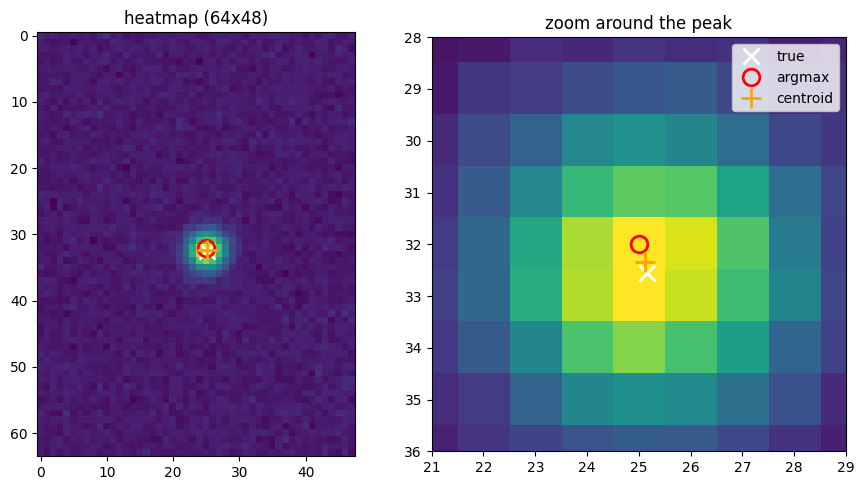

In [29]:
# ヒートマップからキーポイントの座標を取り出す: argmax と、周辺の重心による補正
STRIDE = 4            # 入力画像に対するヒートマップの縮小率
HM_SHAPE = (64, 48)   # ヒートマップの大きさ（高さ, 幅） 入力画像は 256x192 に相当

def gaussian_heatmap(cx, cy, sigma=2.0, noise=0.02, rng=None):
    # (cx, cy) はヒートマップ上の座標（小数を含む）
    ys, xs = np.mgrid[:HM_SHAPE[0], :HM_SHAPE[1]]
    hm = np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * sigma ** 2))
    if rng is not None:
        hm = hm + rng.normal(0, noise, hm.shape)   # ネットワークの出力の乱れを模した雑音
    return hm

def decode_argmax(hm):
    iy, ix = np.unravel_index(hm.argmax(), hm.shape)
    return np.array([ix, iy], dtype=float)

def decode_centroid(hm, win=3):
    # 最大値の周囲 (2*win+1) 四方の窓で、値を重みとした重心を求める
    ix, iy = decode_argmax(hm).astype(int)
    y0, y1 = max(iy - win, 0), min(iy + win + 1, hm.shape[0])
    x0, x1 = max(ix - win, 0), min(ix + win + 1, hm.shape[1])
    patch = np.clip(hm[y0:y1, x0:x1], 0, None)
    ys, xs = np.mgrid[y0:y1, x0:x1]
    return np.array([(patch * xs).sum(), (patch * ys).sum()]) / patch.sum()

# 入力画像上のランダムな位置にキーポイントを置き、復元した座標との誤差（ピクセル）を測る
rng = np.random.default_rng(0)
err_argmax, err_centroid = [], []
for _ in range(1000):
    true_px = rng.uniform([40, 40], [150, 210])            # 入力画像上の真の座標 (x, y)
    hm = gaussian_heatmap(*(true_px / STRIDE), rng=rng)
    err_argmax.append(np.linalg.norm(decode_argmax(hm) * STRIDE - true_px))
    err_centroid.append(np.linalg.norm(decode_centroid(hm) * STRIDE - true_px))
print(f"argmax    の平均誤差: {np.mean(err_argmax):.2f} pixel (最大 {np.max(err_argmax):.2f})")
print(f"重心で補正した平均誤差: {np.mean(err_centroid):.2f} pixel (最大 {np.max(err_centroid):.2f})")

# 1つの例を表示する（右は最大値の周辺の拡大）
true_hm = np.array([100.6, 130.2]) / STRIDE
hm = gaussian_heatmap(*true_hm, rng=rng)
p_arg, p_cen = decode_argmax(hm), decode_centroid(hm)
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
for ax in axes:
    ax.imshow(hm, cmap="viridis")
    ax.plot(*true_hm, "wx", markersize=12, markeredgewidth=2, label="true")
    ax.plot(*p_arg, "o", color="red", fillstyle="none", markersize=12, markeredgewidth=2, label="argmax")
    ax.plot(*p_cen, "+", color="orange", markersize=14, markeredgewidth=2, label="centroid")
axes[0].set_title("heatmap (64x48)")
axes[1].set_xlim(p_arg[0] - 4, p_arg[0] + 4); axes[1].set_ylim(p_arg[1] + 4, p_arg[1] - 4)
axes[1].set_title("zoom around the peak"); axes[1].legend()
plt.tight_layout()
plt.show()

結果の読み方
- argmaxだけでは、平均して1ピクセルを超える誤差が残る
  - ヒートマップの1画素が入力画像の4ピクセルに相当するので、どれだけ学習がうまくいってもこの誤差は消えない
- 周辺の値の重心をとると、誤差は約1/3になる
  - 右の拡大図では、argmax（赤い丸）は画素の中心にしか置けないのに対し、重心（橙の十字）は真の位置（白い×）のすぐ近くにある

この考え方をさらに進めたものが**soft-argmax**である
- ヒートマップ全体をsoftmaxで確率分布に変換し、座標の期待値を出力とする
- argmaxと違って微分できるので、座標の誤差を直接損失にして学習できる
- ヒートマップ方式の空間的な表現と、座標回帰の「座標を直接学習する」利点を組み合わせた方法である

## YOLOのposeモデルによる骨格の描画

学習済みの `yolo11n-pose.pt` を使い、1枚の画像から骨格を描く
- 画像はUltralyticsに同梱されているサンプル（`bus.jpg`）を使う
- 結果の `keypoints.xy` は（人数, 17, 2）の座標、`keypoints.conf` は（人数, 17）の信頼度である
- 仕組みがわかるように、ライブラリの描画機能を使わず、座標から自分で骨格を描く

検出された人数: 4  keypointsの形状: (4, 17, 2)


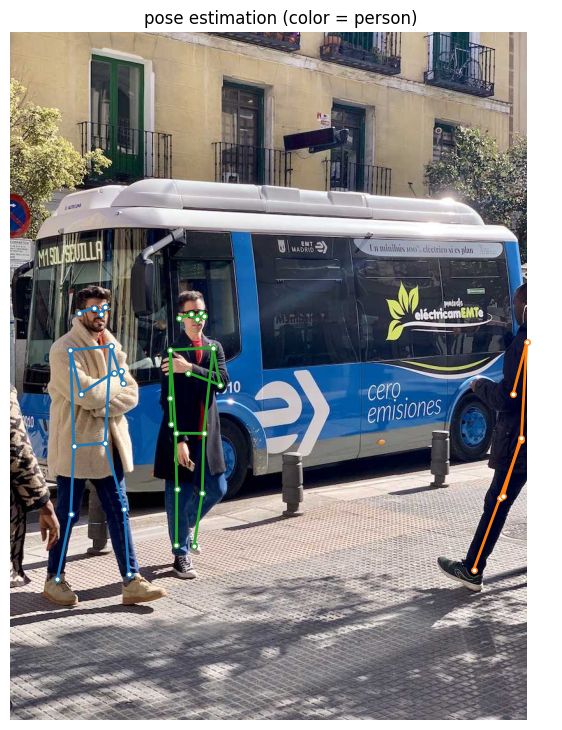

1人目の信頼度: [       0.99        0.93        0.99        0.43        0.93        0.99           1        0.92        0.99         0.9        0.97           1           1        0.99           1        0.98        0.99]


In [30]:
# YOLO11n-poseで姿勢推定を行い、骨格を描画する
from ultralytics import YOLO
from ultralytics.utils import ASSETS
import matplotlib.pyplot as plt

pose_model = YOLO("yolo11n-pose.pt")
result = pose_model(ASSETS / "bus.jpg", verbose=False)[0]

kpts = result.keypoints.xy.cpu().numpy()      # (人数, 17, 2)
kconf = result.keypoints.conf.cpu().numpy()   # (人数, 17)
print("検出された人数:", len(kpts), " keypointsの形状:", kpts.shape)

# COCOの17キーポイントの番号
# 0:鼻 1,2:目 3,4:耳 5,6:肩 7,8:肘 9,10:手首 11,12:腰 13,14:膝 15,16:足首（奇数が左、偶数が右）
skeleton = [(0, 1), (0, 2), (1, 3), (2, 4),             # 顔
            (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),    # 肩と腕
            (5, 11), (6, 12), (11, 12),                 # 胴体
            (11, 13), (13, 15), (12, 14), (14, 16)]     # 脚

plt.figure(figsize=(7, 9))
plt.imshow(result.orig_img[:, :, ::-1])       # BGRをRGBに直して表示
for p in range(len(kpts)):
    color = plt.cm.tab10(p % 10)
    ok = kconf[p] > 0.5                       # 信頼度の低いキーポイントは描かない
    for i, j in skeleton:
        if ok[i] and ok[j]:
            plt.plot(kpts[p, [i, j], 0], kpts[p, [i, j], 1], color=color, linewidth=2)
    plt.scatter(kpts[p, ok, 0], kpts[p, ok, 1], s=15, color="white", edgecolors=color, zorder=3)
plt.axis("off")
plt.title("pose estimation (color = person)")
plt.show()

# 1人目のキーポイントごとの信頼度
print("1人目の信頼度:", np.round(kconf[0], 2))

結果の読み方
- 人ごとに色を変えて、17個のキーポイントとそれらを結ぶ骨格が描かれる
- 画像の端で体が切れている人や、他の人やバスに隠れた部位は、キーポイントの信頼度が低くなり、描画から外れる
  - 信頼度のしきい値（ここでは0.5）を下げると、隠れた部位も推定した位置に描かれる
  - モデルは見えていない関節についても座標を出力しており、それを使うかどうかは利用側が決める

姿勢推定は追跡と組み合わせて使うことが多い
- `pose_model.track(...)` とすれば、人ごとにIDを付けたまま骨格の時系列が得られ、動作の認識に利用できる

## OKSの計算

OKSを実装し、性質を確かめる
- COCOでは、キーポイントの種類ごとに標準偏差 $\sigma_i$ が公開されており、$k_i = 2\sigma_i$ として使う
- $s^2$ は本来、正解の領域（セグメンテーション）の面積である
  - ここでは領域の情報が無いので、箱の面積で代用する
- 正解の注釈も手元に無いので、先ほど推定した1人目のキーポイントを**仮の正解**とし、これをわざとずらしたものを「予測」としてOKSを計算する

In [31]:
# OKS (Object Keypoint Similarity) の計算
# COCOの17キーポイントの標準偏差（鼻、目、耳、肩、肘、手首、腰、膝、足首の順）
COCO_SIGMAS = np.array([.026, .025, .025, .035, .035, .079, .079, .072, .072,
                        .062, .062, .107, .107, .087, .087, .089, .089])

def oks(pred, gt, visible, area):
    # pred, gt: (17, 2)  visible: (17,) 正解のラベルがあるキーポイント  area: 物体の面積 (s^2)
    d2 = ((pred - gt) ** 2).sum(axis=1)
    k = 2 * COCO_SIGMAS
    return float(np.exp(-d2 / (2 * area * k ** 2))[visible].mean())

gt_kpts = kpts[0]                                  # 1人目の推定結果を仮の正解とする
visible = kconf[0] > 0.5
x1, y1, x2, y2 = result.boxes.xyxy[0].cpu().numpy()
area = (x2 - x1) * (y2 - y1)
print(f"箱の大きさ: {x2 - x1:.0f} x {y2 - y1:.0f} pixel")

# (1) 全てのキーポイントを同じ大きさの雑音でずらす  小さく写った人（面積1/16）の場合と比較する
rng = np.random.default_rng(0)
print("ずれの標準偏差 [pixel]   OKS    OKS（面積1/16の場合）")
for noise in [0, 2, 5, 10, 20, 40]:
    vals = [(oks(p, gt_kpts, visible, area), oks(p, gt_kpts, visible, area / 16))
            for p in (gt_kpts + rng.normal(0, noise, gt_kpts.shape) for _ in range(200))]
    print(f"{noise:14d}          {np.mean(vals, axis=0)[0]:.3f}  {np.mean(vals, axis=0)[1]:.3f}")

# (2) 1種類のキーポイントだけを右に15ピクセルずらし、その点の類似度 exp(...) を比べる
names = {0: "nose", 5: "left shoulder", 9: "left wrist", 11: "left hip"}
for i, name in names.items():
    e = np.exp(-15 ** 2 / (2 * area * (2 * COCO_SIGMAS[i]) ** 2))
    print(f"{name:14s} を15ピクセルずらしたときの類似度: {e:.3f}")

箱の大きさ: 196 x 506 pixel
ずれの標準偏差 [pixel]   OKS    OKS（面積1/16の場合）
             0          1.000  1.000
             2          0.996  0.938
             5          0.973  0.757
            10          0.908  0.506
            20          0.753  0.229
            40          0.500  0.075
nose           を15ピクセルずらしたときの類似度: 0.657
left shoulder  を15ピクセルずらしたときの類似度: 0.955
left wrist     を15ピクセルずらしたときの類似度: 0.929
left hip       を15ピクセルずらしたときの類似度: 0.975


結果の読み方
- ずれが0ならOKSは1であり、ずれが大きくなるほど0に近づく
- 同じピクセル数のずれでも、小さく写った人（面積が1/16、つまり縦横が1/4）ではOKSが大きく下がる
  - 物体の大きさで正規化しているためであり、「体の大きさに対してどれだけずれたか」を測っていることになる
- 同じ15ピクセルのずれでも、鼻では類似度が大きく下がり、腰ではあまり下がらない
  - 鼻は位置がはっきり決まるので $k_i$ が小さく、厳しく評価される
  - 腰は服の上からは位置が決めにくく、人が付けた正解自体がばらつくので $k_i$ が大きく、緩く評価される

COCOの姿勢推定のAPは、物体検出のAPのIoUをこのOKSに置き換え、しきい値を0.50から0.95まで変えて平均したものである

## 応用例: 関節角度の計算

キーポイントの座標が得られると、そこから簡単な幾何の計算で体の状態を数値にできる
- 例えば、肩・肘・手首の3点から肘の曲がり角を、腰・膝・足首の3点から膝の曲がり角を求められる
- 点 $B$ における角度は、$B$ から $A$ と $C$ へ向かう2つのベクトルのなす角である

$$\theta = \arccos \frac{(A - B)\cdot(C - B)}{\|A - B\|\,\|C - B\|}$$

- 腕や脚をまっすぐ伸ばすと180度に近づき、曲げると小さくなる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/pose-joint-angle.png" width=600>

上の図は、肘の角度の例である
- 肩、肘、手首の3点のうち、中央の肘の位置で角度を測る

person 0: L elbow  11.3, R elbow  70.6, L knee 168.0, R knee 171.0
person 1: L knee 180.0
person 2: L elbow  58.7, R elbow 177.1, L knee 172.6, R knee 178.5
person 3: (信頼できるキーポイントの組が無い)


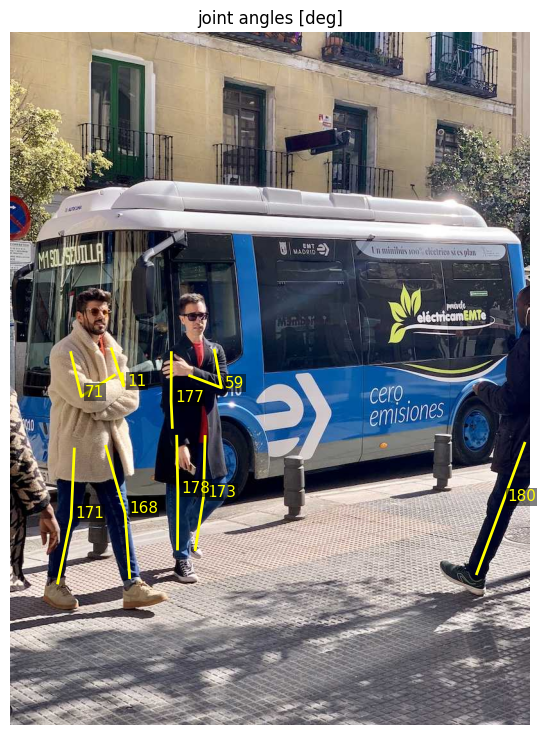

In [32]:
# キーポイントから肘と膝の角度を求め、画像に書き込む
def joint_angle(a, b, c):
    # 点bにおける、b→a と b→c のなす角（度）
    v1, v2 = a - b, c - b
    cos = v1 @ v2 / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return float(np.degrees(np.arccos(np.clip(cos, -1, 1))))

# (名前, 3点のキーポイント番号) 角度は中央の点で測る
joints = [("L elbow", (5, 7, 9)), ("R elbow", (6, 8, 10)),
          ("L knee", (11, 13, 15)), ("R knee", (12, 14, 16))]

plt.figure(figsize=(7, 9))
plt.imshow(result.orig_img[:, :, ::-1])
for p in range(len(kpts)):
    row = []
    for name, (i, j, k) in joints:
        if min(kconf[p, [i, j, k]]) > 0.5:          # 3点とも信頼できる場合だけ計算する
            ang = joint_angle(kpts[p, i], kpts[p, j], kpts[p, k])
            row.append(f"{name} {ang:5.1f}")
            plt.plot(kpts[p, [i, j, k], 0], kpts[p, [i, j, k], 1], color="yellow", linewidth=2)
            plt.text(kpts[p, j, 0] + 6, kpts[p, j, 1], f"{ang:.0f}", color="yellow", fontsize=11,
                     bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"))
    print(f"person {p}:", ", ".join(row) if row else "(信頼できるキーポイントの組が無い)")
plt.axis("off")
plt.title("joint angles [deg]")
plt.show()

結果の読み方
- 腕を体の前で曲げている人は肘の角度が小さく、伸びている脚の膝の角度は180度に近い
- 画像の端で体が切れている人は、3点がそろわないので角度が計算されない

この種の計算は、姿勢推定の実用で広く使われている
- 膝の角度の時系列から、スクワットの回数を数える（角度がしきい値を下回って、再び上回るごとに1回）
- 肘や肩の角度から、作業姿勢の負担やスポーツのフォームを評価する
- 体幹の傾きや腰の高さの急な変化から、転倒を検知する

注意点
- ここで求めたのは、画像に投影された2次元上の角度である
  - カメラに向かって腕を伸ばすと、実際には伸びていても画像上では短く写り、角度も変わる
  - 実際の3次元の角度が必要な場合は、複数のカメラや、2次元の姿勢から3次元の姿勢を推定するモデルを使う
- 時系列で使う場合は、フレームごとの推定のぶれを平滑化する
  - ここでも、追跡で学んだカルマンフィルタが使える

# 課題
データオーグメンテーションを実装しなさい
- どのような形でも構わないが、ここではBounding Boxも変換することを忘れずに

# 課題2（追跡器の改良と評価）

自作した追跡器を改良し、評価指標で効果を確かめよ

1. `KalmanTracker` を継承し、新しいトラックをすぐには出力せず、`n_init` フレーム続けて対応が付いた時点から出力する追跡器を実装せよ
   - それまでの間は、`update` の戻り値のIDを-1とすること
2. スコア付きの合成データ `frames_scored` の全ての検出（スコア0.1以上）をこの追跡器に渡し、`n_init` を1、2、3と変えたときのFN、FP、IDスイッチ、MOTA、IDF1を `print_metrics` で表にせよ
3. 2の結果を `ByteTracker` の結果と比較し、誤検出を抑える2つの方法（確定までの待ち、低スコアの検出から新しいトラックを作らない）の長所と短所を考察せよ
4. 途中で進行方向を反転する物体を含む合成データを自分で作り、`KalmanTracker` の `q` を0.01、0.05、1.0と変えて追跡せよ
   - 等速運動の仮定が外れたときに何が起こるか、`q` がそれにどう影響するかを、`plot_tracks` の図とIDF1から説明すること

# 課題3（関節角度の時系列）

人が運動している短い動画（スクワット、腕の曲げ伸ばしなど）を用意し、姿勢推定と追跡を組み合わせて動作を数値化せよ

1. `pose_model.track(動画, stream=True)` により、フレームごとに各人のIDとキーポイントを取得せよ
2. 1人を選び、`joint_angle` を使って膝または肘の角度の時系列を求め、横軸をフレーム番号としてグラフに描け
   - キーポイントの信頼度が低いフレームは除くこと
3. 角度の時系列を平滑化し（移動平均でよい）、しきい値を用いて動作の回数を数えよ
4. 数え間違いが起こる場合は、その原因を姿勢推定の誤り、追跡の誤り、2次元への投影の影響に分けて考察せよ

# 参考文献

- Redmon, J. et al. (2016). "You Only Look Once: Unified, Real-Time Object Detection." CVPR 2016.
- Liu, W. et al. (2016). "SSD: Single Shot MultiBox Detector." ECCV 2016.
- Lin, T.-Y. et al. (2017). "Feature Pyramid Networks for Object Detection." CVPR 2017.
- Redmon, J. & Farhadi, A. (2018). "YOLOv3: An Incremental Improvement." arXiv:1804.02767.
- Bochkovskiy, A. et al. (2020). "YOLOv4: Optimal Speed and Accuracy of Object Detection." arXiv:2004.10934.
- Jocher, G. et al. (2020). "YOLOv5." https://github.com/ultralytics/yolov5
- Li, C. et al. (2023). "YOLOv6 v3.0: A Full-Scale Reloading." arXiv:2301.05586.
- Wang, C.-Y. et al. (2023). "YOLOv7: Trainable Bag-of-Freebies Sets New State-of-the-Art for Real-Time Object Detectors." CVPR 2023.
- Jocher, G. et al. (2023). "YOLOv8." https://github.com/ultralytics/ultralytics
- Wang, C.-Y. et al. (2024). "YOLOv9: Learning What You Want to Learn Using Programmable Gradient Information." ECCV 2024.
- Wang, A. et al. (2024). "YOLOv10: Real-Time End-to-End Object Detection." arXiv:2405.14458.
- Jocher, G. et al. (2024). "YOLO11." https://docs.ultralytics.com/models/yolo11/
- Cheng, T. et al. (2024). "YOLO-World: Real-Time Open-Vocabulary Object Detection." CVPR 2024.
- Kuhn, H. W. (1955). "The Hungarian Method for the Assignment Problem." Naval Research Logistics Quarterly.
- Bewley, A. et al. (2016). "Simple Online and Realtime Tracking." ICIP 2016.
- Wojke, N. et al. (2017). "Simple Online and Realtime Tracking with a Deep Association Metric." ICIP 2017.
- Zhang, Y. et al. (2022). "ByteTrack: Multi-Object Tracking by Associating Every Detection Box." ECCV 2022.
- Lin, T.-Y. et al. (2014). "Microsoft COCO: Common Objects in Context." ECCV 2014.
- Cao, Z. et al. (2017). "Realtime Multi-Person 2D Pose Estimation using Part Affinity Fields." CVPR 2017.
- Sun, K. et al. (2019). "Deep High-Resolution Representation Learning for Human Pose Estimation." CVPR 2019.
- Maji, D. et al. (2022). "YOLO-Pose: Enhancing YOLO for Multi Person Pose Estimation Using Object Keypoint Similarity Loss." CVPR Workshops 2022.
- Kalman, R. E. (1960). "A New Approach to Linear Filtering and Prediction Problems." Journal of Basic Engineering.
- Bernardin, K. & Stiefelhagen, R. (2008). "Evaluating Multiple Object Tracking Performance: The CLEAR MOT Metrics." EURASIP Journal on Image and Video Processing.
- Ristani, E. et al. (2016). "Performance Measures and a Data Set for Multi-Target, Multi-Camera Tracking." ECCV 2016 Workshops.
- Luiten, J. et al. (2021). "HOTA: A Higher Order Metric for Evaluating Multi-Object Tracking." International Journal of Computer Vision.
- Aharon, N. et al. (2022). "BoT-SORT: Robust Associations Multi-Pedestrian Tracking." arXiv:2206.14651.
- Sun, X. et al. (2018). "Integral Human Pose Regression." ECCV 2018.